# 🧠 Neural Networks From Scratch — Backprop, Autograd, and Optimizers by Hand

> **What you'll learn:** what a neuron really computes, why networks need non-linear activations, how the forward pass and softmax cross-entropy work, how to derive **backpropagation** by hand, how to build a tiny **autograd engine** like PyTorch's, how to **check gradients**, why initialization matters, how SGD / Momentum / RMSProp / Adam work, and how dropout and L2 fight overfitting — all in NumPy, verified against PyTorch.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced (every term is defined as we go) |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Math for ML](../01_Core_Scientific_Computing/04_Math_for_ML.ipynb) (derivatives, chain rule, matrix multiply) · [ML Fundamentals From Scratch](../03_Classical_Machine_Learning/01_ML_Fundamentals_From_Scratch.ipynb) (logistic regression, gradient descent, train/val/test) |
| **Tested with** | Python 3.12 · numpy 2.5 · scipy 1.18 · scikit-learn 1.9 (datasets) · torch 2.14 (only to verify our gradients) |
| **Interview relevance** | ⭐⭐⭐ High — "derive backprop for this layer", "why ReLU?", "softmax + cross-entropy gradient", vanishing gradients, Adam vs SGD, dropout at train vs eval |

## 🤔 What Is a Neural Network?

A **neural network** is a function built from many tiny, simple pieces called **neurons**. Each neuron does two things:

1. **Weighs its inputs** — multiply each input by a *weight* (how much that input matters) and add a *bias* (a baseline).
2. **Squashes the result** with an **activation function** — a simple non-linear curve such as "keep positives, zero out negatives".

**Analogy — a panel of judges.** Picture a talent show. Each judge in the first row looks at the raw performance and gives a score based on what *they* care about (one likes rhythm, another likes lyrics). The second row of judges does not watch the show — they only read the first row's scores and combine them. The final judge reads the second row and announces "winner" or "not". No single judge is clever, but the *panel* can make surprisingly subtle decisions. **Training** = adjusting how much each judge trusts each input until the panel's answers match the correct ones.

```
 inputs          hidden layer            output layer
 x1 ──┐        ┌─(neuron)─┐
 x2 ──┼──W1──► ├─(neuron)─┼──W2──► (neuron) → scores for each class → probabilities
 x3 ──┘        └─(neuron)─┘
```

**Backpropagation** is how the network learns: after it makes a prediction and we measure the error (the **loss**), we use the chain rule from calculus to work out, for *every* weight, "if I nudge this weight up, does the loss go up or down, and by how much?" That number is the **gradient**. Then an **optimizer** nudges every weight a little in the direction that reduces the loss.

## 🎯 Why It Matters

- **Every modern AI model is this, scaled up.** ChatGPT, image generators, and speech models are stacks of the same ingredients you build here: linear layers, activations, a loss, backprop, and Adam.
- **Frameworks hide it — until something breaks.** PyTorch computes gradients for you, but when your loss is `nan`, stuck at 2.30, or your validation accuracy collapses, you need to know what happens underneath to debug it.
- **In interviews** this is a favourite topic for ML engineer roles: *"derive the gradient of softmax cross-entropy"*, *"implement backprop for a 2-layer network in NumPy"*, *"why do we need non-linearities?"*, *"explain vanishing gradients"*, *"how does Adam work?"*, *"what does dropout do at inference time?"*. This notebook makes you practise every one of those out loud and in code.

## ✅ By the End You Can

- [ ] Explain neurons, activations, and why a stack of linear layers without them is still just one linear layer
- [ ] Derive and implement backpropagation for a 2-layer network, and prove it correct with gradient checking
- [ ] Build a micrograd-style scalar **autograd engine** and verify it against PyTorch autograd
- [ ] Choose an initialization (Xavier / He) and diagnose vanishing or exploding gradients
- [ ] Implement SGD, Momentum, RMSProp, Adam, L2, and inverted dropout from scratch and compare them
- [ ] Train a NumPy digit classifier with early stopping and compare it with an equivalent PyTorch model

## 📋 Table of Contents

1. [The Neuron and the Perceptron](#1.-The-Neuron-and-the-Perceptron-🟢)
2. [Why Non-Linearity?](#2.-Why-Non-Linearity?-🟢)
3. [Activation Functions and Their Gradients](#3.-Activation-Functions-and-Their-Gradients-🟢)
4. [The Forward Pass of an MLP — Follow the Shapes](#4.-The-Forward-Pass-of-an-MLP-—-Follow-the-Shapes-🟢)
5. [Softmax and Cross-Entropy Loss](#5.-Softmax-and-Cross-Entropy-Loss-🟡)
6. [Backpropagation by Hand](#6.-Backpropagation-by-Hand-🟡)
7. [Gradient Checking](#7.-Gradient-Checking-🟡)
8. [A Micrograd-Style Autograd Engine](#8.-A-Micrograd-Style-Autograd-Engine-🔴)
9. [Vectorized Layers: A Mini Framework](#9.-Vectorized-Layers:-A-Mini-Framework-🟡)
10. [Weight Initialization and Vanishing / Exploding Gradients](#10.-Weight-Initialization-and-Vanishing-/-Exploding-Gradients-🟡)
11. [Mini-Batching and SGD](#11.-Mini-Batching-and-SGD-🟢)
12. [Optimizers From Scratch: SGD, Momentum, RMSProp, Adam](#12.-Optimizers-From-Scratch:-SGD,-Momentum,-RMSProp,-Adam-🟡)
13. [Regularization: L2 and Inverted Dropout](#13.-Regularization:-L2-and-Inverted-Dropout-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-NumPy-Digit-Classifier-vs-PyTorch) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

We write everything in **NumPy**. PyTorch is imported only to *check* our gradients and, at the very end, to compare against a real framework.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "numpy>=2.0" "scipy>=1.11" "scikit-learn>=1.5" matplotlib "torch>=2.4"

import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy
import sklearn
import torch
import torch.nn.functional as F
from scipy.special import erf
from sklearn.datasets import load_digits, load_iris
from sklearn.model_selection import train_test_split

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | SciPy {scipy.__version__} | "
      f"scikit-learn {sklearn.__version__} | torch {torch.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)          # one seeded generator for the notebook
torch.manual_seed(SEED)
np.set_printoptions(precision=4, suppress=True)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-5, atol=1e-8):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    got_arr, exp_arr = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
    if got_arr.shape != exp_arr.shape:
        raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
    assert np.allclose(got_arr, exp_arr, rtol=rtol, atol=atol), f"❌ {name}: values are not quite right. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | NumPy 2.5.3 | SciPy 1.18.1 | scikit-learn 1.9.1 | torch 2.14.0


## 1. The Neuron and the Perceptron 🟢

A single **neuron** computes

$$\text{output} = \text{activation}(w_1 x_1 + w_2 x_2 + \dots + w_d x_d + b) = \text{activation}(\mathbf{w} \cdot \mathbf{x} + b)$$

- **weights** $\mathbf{w}$ — how strongly each input pushes the decision
- **bias** $b$ — shifts the decision threshold
- **activation** — the non-linear "squash" applied at the end

The **perceptron** (Rosenblatt, 1958) is the oldest neural network: one neuron with a *step* activation (output 1 if the sum is positive, else 0). Its learning rule is simple: when it gets an example wrong, move the weights toward the correct answer: $\mathbf{w} \leftarrow \mathbf{w} + \eta\,(y - \hat y)\,\mathbf{x}$, where $\eta$ (eta) is the **learning rate** (step size).

In [2]:
def neuron(x, w, b, activation):
    return activation(x @ w + b)


step = lambda z: (z > 0).astype(float)

# A hand-made neuron: "go for a run?" from [sunny (0/1), free time in hours]
w_run, b_run = np.array([1.5, 1.0]), -2.0
for x in ([1, 1.0], [0, 1.0], [1, 0.25], [0, 3.0]):
    print(f"sunny={x[0]}, free hours={x[1]:.2f} → weighted sum {np.dot(x, w_run) + b_run:+.2f} → run? {neuron(np.array(x), w_run, b_run, step):.0f}")

sunny=1, free hours=1.00 → weighted sum +0.50 → run? 1
sunny=0, free hours=1.00 → weighted sum -1.00 → run? 0
sunny=1, free hours=0.25 → weighted sum -0.25 → run? 0
sunny=0, free hours=3.00 → weighted sum +1.00 → run? 1


Now let the perceptron **learn** its weights on real data: telling *Iris setosa* from *Iris versicolor* flowers using petal length and width (a classic dataset measured by botanists in the 1930s).

In [3]:
def train_perceptron(X, y, lr=0.1, epochs=20):
    w, b = np.zeros(X.shape[1]), 0.0
    accuracy_per_epoch = []
    for _ in range(epochs):
        for xi, yi in zip(X, y):
            y_hat = float(xi @ w + b > 0)
            w += lr * (yi - y_hat) * xi          # no change when the prediction is right
            b += lr * (yi - y_hat)
        accuracy_per_epoch.append(float(((X @ w + b > 0) == y).mean()))
    return w, b, accuracy_per_epoch


iris = load_iris()
two_species = iris.target < 2                                  # setosa (0) vs versicolor (1)
X_iris2 = iris.data[two_species][:, 2:4]                       # petal length, petal width (cm)
y_iris2 = iris.target[two_species].astype(float)
w_p, b_p, acc_p = train_perceptron(X_iris2, y_iris2)
print("learned weights:", w_p, "bias:", round(b_p, 3))
print("accuracy per epoch:", acc_p[:6], "...")
print(f"final accuracy on setosa vs versicolor: {acc_p[-1]:.0%}")

learned weights: [0.06 0.08] bias: -0.2
accuracy per epoch: [0.5, 1.0, 1.0, 1.0, 1.0, 1.0] ...
final accuracy on setosa vs versicolor: 100%


A perceptron can only draw a **straight line** (a *hyperplane* in more dimensions) between classes. The famous counter-example is **XOR** ("exactly one of two inputs is on"). This is a deliberately tiny *synthetic* example — four points — because it isolates the idea.

In [4]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)
_, _, acc_xor = train_perceptron(X_xor, y_xor, epochs=100)
print(f"best perceptron accuracy on XOR over 100 epochs: {max(acc_xor):.0%}")
if max(acc_xor) < 1.0:
    print("→ no straight line separates XOR: one neuron is not enough.")

best perceptron accuracy on XOR over 100 epochs: 50%
→ no straight line separates XOR: one neuron is not enough.


### ✍️ Your Turn

Compute the output of a neuron with inputs `x = [0.5, -1.0, 2.0]`, weights `w = [0.2, 0.4, -0.1]`, bias `b = 0.3`, and a **ReLU** activation (`max(0, z)`).

In [5]:
x_in = np.array([0.5, -1.0, 2.0])
w_in = np.array([0.2, 0.4, -0.1])
b_in = 0.3
neuron_out = None  # TODO: weighted sum, then ReLU
check("neuron_out", neuron_out, 0.0, hint="z = x_in @ w_in + b_in = 0.1 - 0.4 - 0.2 + 0.3. What does ReLU do to it?")

⏳ neuron_out: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_in = np.array([0.5, -1.0, 2.0])
w_in = np.array([0.2, 0.4, -0.1])
b_in = 0.3
neuron_out = max(0.0, x_in @ w_in + b_in)
check("neuron_out", neuron_out, 0.0)
```

The weighted sum is `0.1 − 0.4 − 0.2 + 0.3 = −0.2`, and ReLU turns any negative number into 0. (This neuron is "off" for this input — it passes no gradient back, which matters later.)
</details>

> 💡 **Interview angle:** "Why can't a single perceptron learn XOR?" — it computes a linear decision boundary, and XOR's positive points sit on opposite corners, so no single line separates them. A hidden layer with a non-linearity fixes it.

## 2. Why Non-Linearity? 🟢

What if we stack two layers *without* activations? Layer 1 computes $W_1 x + b_1$, layer 2 computes $W_2(W_1 x + b_1) + b_2$. Expand it:

$$W_2 W_1 x + (W_2 b_1 + b_2) = W x + b$$

That is **one** linear layer in disguise. A hundred linear layers are still one linear layer — they can only draw straight boundaries. The **activation function** is what lets stacked layers bend the boundary into any shape.

In [6]:
W1_demo, b1_demo = rng.normal(size=(5, 3)), rng.normal(size=5)
W2_demo, b2_demo = rng.normal(size=(2, 5)), rng.normal(size=2)
x_demo = rng.normal(size=3)

two_linear_layers = W2_demo @ (W1_demo @ x_demo + b1_demo) + b2_demo
W_merged, b_merged = W2_demo @ W1_demo, W2_demo @ b1_demo + b2_demo
print("two linear layers :", two_linear_layers)
print("one merged layer  :", W_merged @ x_demo + b_merged)
print("identical?", np.allclose(two_linear_layers, W_merged @ x_demo + b_merged))

two linear layers : [ 0.8179 -0.2977]
one merged layer  : [ 0.8179 -0.2977]
identical? True


With a **ReLU** in the middle, two layers *can* solve XOR. These weights were chosen by hand to show it is possible:

- hidden unit 1: $h_1 = \text{ReLU}(x_1 + x_2)$ — "at least one is on"
- hidden unit 2: $h_2 = \text{ReLU}(x_1 + x_2 - 1)$ — "both are on"
- output: $h_1 - 2h_2$

In [7]:
W_h, b_h = np.array([[1.0, 1.0], [1.0, 1.0]]), np.array([0.0, -1.0])
w_o = np.array([1.0, -2.0])
hidden = np.maximum(X_xor @ W_h.T + b_h, 0)
xor_out = hidden @ w_o
for x, h, o in zip(X_xor, hidden, xor_out):
    print(f"x={x} → hidden={h} → output={o:.0f}")
print("matches XOR labels:", np.array_equal(xor_out, y_xor))

x=[0. 0.] → hidden=[0. 0.] → output=0
x=[0. 1.] → hidden=[1. 0.] → output=1
x=[1. 0.] → hidden=[1. 0.] → output=1
x=[1. 1.] → hidden=[2. 1.] → output=0
matches XOR labels: True


### ✍️ Your Turn

Two linear layers (no activation) are given. Compute the **single** equivalent layer `W_single`, `b_single` so that `X @ W_single.T + b_single` gives exactly the same outputs as the two layers.

In [8]:
ex_rng = np.random.default_rng(7)
A1_w, A1_b = ex_rng.normal(size=(4, 3)), ex_rng.normal(size=4)
A2_w, A2_b = ex_rng.normal(size=(2, 4)), ex_rng.normal(size=2)
X_probe = ex_rng.normal(size=(6, 3))
two_layer_outputs = (X_probe @ A1_w.T + A1_b) @ A2_w.T + A2_b

W_single = None  # TODO
b_single = None  # TODO
check("merged_layer", None if W_single is None else X_probe @ W_single.T + b_single, two_layer_outputs,
      hint="Expand W2 (W1 x + b1) + b2: the weight is a matrix product and the bias picks up W2 @ b1.")

⏳ merged_layer: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ex_rng = np.random.default_rng(7)
A1_w, A1_b = ex_rng.normal(size=(4, 3)), ex_rng.normal(size=4)
A2_w, A2_b = ex_rng.normal(size=(2, 4)), ex_rng.normal(size=2)
X_probe = ex_rng.normal(size=(6, 3))
two_layer_outputs = (X_probe @ A1_w.T + A1_b) @ A2_w.T + A2_b
W_single = A2_w @ A1_w                 # (2, 4) @ (4, 3) → (2, 3)
b_single = A2_w @ A1_b + A2_b          # (2,)
check("merged_layer", X_probe @ W_single.T + b_single, two_layer_outputs)
```
</details>

> 💡 **Interview angle:** "Why do neural networks need activation functions?" — without them, any depth collapses to one linear map ($W = W_L \cdots W_1$), so the model is no more expressive than linear regression. Non-linearities are what make depth useful.

## 3. Activation Functions and Their Gradients 🟢

Backprop needs the **derivative** (slope) of every activation. The slope decides how much gradient flows back through a neuron.

| Activation | Formula | Derivative | Range | Where you see it |
|---|---|---|---|---|
| **Sigmoid** $\sigma$ | $\frac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z))$ — at most **0.25** | (0, 1) | binary output probabilities, gates in LSTMs |
| **tanh** | $\frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $1 - \tanh^2(z)$ — at most 1 | (−1, 1) | RNNs, older MLPs |
| **ReLU** | $\max(0, z)$ | 1 if $z>0$ else 0 | [0, ∞) | default for CNNs and MLPs |
| **GELU** | $z\,\Phi(z)$ ($\Phi$ = normal CDF) | $\Phi(z) + z\,\varphi(z)$ | ≈ (−0.17, ∞) | BERT, GPT-2/3, ViT |

**Saturation** = the curve goes flat, so the derivative is ≈ 0 and almost no gradient passes. Sigmoid and tanh saturate for large |z|; ReLU never saturates for positive inputs.

In [9]:
def sigmoid(z):
    return np.exp(-np.logaddexp(0.0, -z))      # = 1 / (1 + e^-z), without overflow for very negative z


def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1 - s)


def tanh_prime(z):
    return 1 - np.tanh(z) ** 2


def relu_prime(z):
    return (z > 0).astype(float)


def gelu(z):
    return 0.5 * z * (1 + erf(z / np.sqrt(2)))


def gelu_prime(z):
    cdf = 0.5 * (1 + erf(z / np.sqrt(2)))
    pdf = np.exp(-0.5 * z ** 2) / np.sqrt(2 * np.pi)
    return cdf + z * pdf


activations = {
    "sigmoid": (sigmoid, sigmoid_prime),
    "tanh": (np.tanh, tanh_prime),
    "ReLU": (lambda z: np.maximum(z, 0), relu_prime),
    "GELU": (gelu, gelu_prime),
}

# Verify every derivative with a finite difference (skip z=0 exactly, where ReLU has a kink)
z_grid = np.linspace(-4, 4, 801)
z_grid = z_grid[np.abs(z_grid) > 1e-6]
h = 1e-6
for name, (f, f_prime) in activations.items():
    numeric = (f(z_grid + h) - f(z_grid - h)) / (2 * h)
    print(f"{name:7s} derivative matches finite difference: {np.allclose(numeric, f_prime(z_grid), atol=1e-6)} "
          f"| max slope = {f_prime(z_grid).max():.3f}")

# Our GELU is the exact formula PyTorch uses by default
z_t = torch.linspace(-4, 4, 101, dtype=torch.float64)
assert torch.allclose(F.gelu(z_t), torch.from_numpy(gelu(z_t.numpy())))
print("GELU matches torch.nn.functional.gelu ✅")

sigmoid derivative matches finite difference: True | max slope = 0.250
tanh    derivative matches finite difference: True | max slope = 1.000
ReLU    derivative matches finite difference: True | max slope = 1.000
GELU    derivative matches finite difference: True | max slope = 1.129
GELU matches torch.nn.functional.gelu ✅


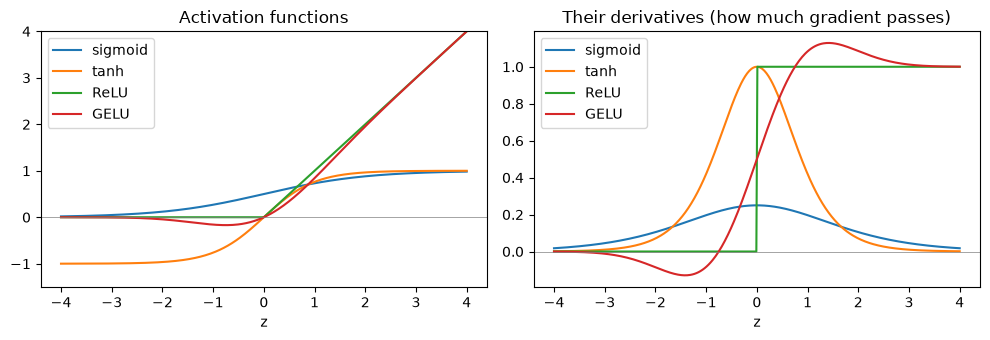

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
z_plot = np.linspace(-4, 4, 400)
for name, (f, f_prime) in activations.items():
    axes[0].plot(z_plot, f(z_plot), label=name)
    axes[1].plot(z_plot, f_prime(z_plot), label=name)
axes[0].set(title="Activation functions", xlabel="z", ylim=(-1.5, 4))
axes[1].set(title="Their derivatives (how much gradient passes)", xlabel="z")
for ax in axes:
    ax.axhline(0, color="gray", lw=0.5)
    ax.legend()
plt.tight_layout()
plt.show()

Notice on the right: the sigmoid slope never exceeds 0.25. Stack 10 sigmoid layers and the gradient can shrink by up to $0.25^{10} \approx 10^{-6}$ — the **vanishing gradient** problem (Section 10 shows it for real).

### ✍️ Your Turn

Implement the derivative of the sigmoid **using only `sigmoid`** (no `sigmoid_prime`) and evaluate it at `z = [-2, 0, 2]`.

In [11]:
z_test = np.array([-2.0, 0.0, 2.0])
sig_grad = None  # TODO
check("sigmoid_grad", sig_grad, [0.10499359, 0.25, 0.10499359], hint="σ'(z) = σ(z) · (1 − σ(z)).")

⏳ sigmoid_grad: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
z_test = np.array([-2.0, 0.0, 2.0])
s = sigmoid(z_test)
sig_grad = s * (1 - s)
check("sigmoid_grad", sig_grad, [0.10499359, 0.25, 0.10499359])
```

This "derivative in terms of the output" trick is why sigmoid was popular: the backward pass can reuse the forward result.
</details>

> 💡 **Interview angle:** "Why is ReLU the default instead of sigmoid?" — its gradient is exactly 1 for positive inputs (no saturation, so gradients don't vanish), it's cheap to compute, and it gives sparse activations. Mention its weakness: **dying ReLU** (a unit stuck at z<0 gets zero gradient forever), and that transformers use smooth variants like GELU.

## 4. The Forward Pass of an MLP — Follow the Shapes 🟢

A **multi-layer perceptron (MLP)** is a stack of *fully connected* (linear) layers with activations in between. The **forward pass** = running the input through each layer in order.

We will classify real handwritten digits: scikit-learn's `load_digits` has **1,797 grayscale 8×8 images** (64 pixels, values 0–16) of the digits 0–9. We split them **once** into train / validation / test (60 / 20 / 20) and leave the **test set untouched until the mini project**.

Following PyTorch's convention, a linear layer stores its weight as `(out_features, in_features)` and computes `X @ W.T + b` for a batch `X` of shape `(batch, in_features)`.

train (1077, 64) | val (360, 64) | test (360, 64) (test is not used until the project)
train class counts: [106 109 107 109 109 109 109 107 104 108]


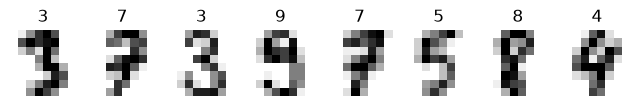

In [12]:
digits = load_digits()
X_all = digits.data / 16.0                  # scale pixels to [0, 1] with a fixed constant (no data-dependent leakage)
y_all = digits.target

X_trval, X_test, y_trval, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_trval, y_trval, test_size=0.25, stratify=y_trval, random_state=SEED)
print(f"train {X_train.shape} | val {X_val.shape} | test {X_test.shape} (test is not used until the project)")
print("train class counts:", np.bincount(y_train))

fig, axes = plt.subplots(1, 8, figsize=(8, 1.4))
for ax, img, label in zip(axes, X_train[:8], y_train[:8]):
    ax.imshow(img.reshape(8, 8), cmap="gray_r")
    ax.set_title(str(label))
    ax.axis("off")
plt.show()

In [13]:
def relu(z):
    return np.maximum(z, 0)


def init_mlp(sizes, seed=0):
    """He-normal weights (explained in Section 10), zero biases. sizes like [64, 128, 10]."""
    r = np.random.default_rng(seed)
    params = {}
    for i, (fan_in, fan_out) in enumerate(zip(sizes[:-1], sizes[1:]), start=1):
        params[f"W{i}"] = r.normal(0.0, np.sqrt(2.0 / fan_in), size=(fan_out, fan_in))
        params[f"b{i}"] = np.zeros(fan_out)
    return params


params = init_mlp([64, 128, 10])
X_batch, y_batch = X_train[:32], y_train[:32]

Z1 = X_batch @ params["W1"].T + params["b1"]   # pre-activation of the hidden layer
A1 = relu(Z1)                                   # hidden activations
Z2 = A1 @ params["W2"].T + params["b2"]         # output scores ("logits"), one per class

for name, arr in [("X", X_batch), ("W1", params["W1"]), ("b1", params["b1"]), ("Z1 = X@W1.T+b1", Z1),
                  ("A1 = relu(Z1)", A1), ("W2", params["W2"]), ("Z2 = logits", Z2)]:
    print(f"{name:16s} shape {str(arr.shape):>10s}")
print("total parameters:", sum(p.size for p in params.values()))
print("untrained predictions:", Z2.argmax(axis=1)[:10], "| true:", y_batch[:10])

X                shape   (32, 64)
W1               shape  (128, 64)
b1               shape     (128,)
Z1 = X@W1.T+b1   shape  (32, 128)
A1 = relu(Z1)    shape  (32, 128)
W2               shape  (10, 128)
Z2 = logits      shape   (32, 10)
total parameters: 9610
untrained predictions: [5 5 5 8 5 5 3 9 5 9] | true: [3 7 3 9 7 5 8 4 7 0]


**Reading the shapes:** `(32, 64) @ (128, 64).T` → `(32, 128)`. The bias `(128,)` broadcasts over the 32 rows. Parameters per linear layer = `in × out + out` → `64×128 + 128 = 8,320` and `128×10 + 10 = 1,290`.

### ✍️ Your Turn

How many trainable parameters does an MLP with layer sizes `[64, 32, 16, 10]` have? Compute it with code (a loop or `zip`), not by hand.

In [14]:
sizes_ex = [64, 32, 16, 10]
n_params_ex = None  # TODO
check("n_params", n_params_ex, 2778, hint="Sum fan_in * fan_out + fan_out over zip(sizes[:-1], sizes[1:]).")

⏳ n_params: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
sizes_ex = [64, 32, 16, 10]
n_params_ex = sum(fan_in * fan_out + fan_out for fan_in, fan_out in zip(sizes_ex[:-1], sizes_ex[1:]))
check("n_params", n_params_ex, 2778)
```

`64·32+32 = 2080`, `32·16+16 = 528`, `16·10+10 = 170` → 2,778.
</details>

> 💡 **Interview angle:** Interviewers often ask you to *narrate shapes* through a network. Say "batch first": `(B, in) → (B, hidden) → (B, classes)`, and that a linear layer has `in·out + out` parameters.

## 5. Softmax and Cross-Entropy Loss 🟡

The network outputs **logits** — raw scores that can be any real number. To turn them into probabilities we use **softmax**:

$$p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

The **cross-entropy loss** for one example with true class $y$ is $L = -\log p_y$: small when the model puts high probability on the right answer, huge when it is confidently wrong. We average it over the batch.

**The famous gradient.** For one example, $L = -z_y + \log\sum_j e^{z_j}$. Differentiate with respect to logit $z_k$:

$$\frac{\partial L}{\partial z_k} = -\mathbb{1}[k=y] + \frac{e^{z_k}}{\sum_j e^{z_j}} = p_k - y_k$$

where $y_k$ is the **one-hot** label (1 for the true class, 0 elsewhere). So the gradient is simply **"predicted probabilities minus the truth"** — divided by the batch size when the loss is a mean.

**Numerical stability:** computing `log(softmax(z))` in two steps can produce `log(0) = -inf`. We use the **log-sum-exp trick**: subtract the max logit first, then take logs directly.

In [15]:
def log_softmax(Z):
    Z_shift = Z - Z.max(axis=1, keepdims=True)           # largest logit becomes 0 → exp can't overflow
    return Z_shift - np.log(np.exp(Z_shift).sum(axis=1, keepdims=True))


def softmax(Z):
    return np.exp(log_softmax(Z))


def cross_entropy(logits, y):
    return -log_softmax(logits)[np.arange(len(y)), y].mean()


loss_init = cross_entropy(Z2, y_batch)
torch_loss = F.cross_entropy(torch.from_numpy(Z2), torch.from_numpy(y_batch))
assert np.isclose(loss_init, torch_loss.item())
print(f"our loss {loss_init:.4f} == torch F.cross_entropy {torch_loss.item():.4f} ✅")
print(f"loss with near-zero logits: {cross_entropy(Z2 * 1e-4, y_batch):.4f} vs ln(10) = {np.log(10):.4f}")

# Verify the gradient p − y with finite differences on one example
z_one, label_one = np.array([[2.0, 1.0, 0.1]]), np.array([0])
analytic = softmax(z_one) - np.eye(3)[label_one]
eps = 1e-6
numeric = np.array([(cross_entropy(z_one + eps * e, label_one) - cross_entropy(z_one - eps * e, label_one)) / (2 * eps)
                    for e in np.eye(3)])
print("p − y      :", analytic.ravel())
print("numerical  :", numeric)
print("match:", np.allclose(analytic.ravel(), numeric, atol=1e-8))

our loss 2.5109 == torch F.cross_entropy 2.5109 ✅
loss with near-zero logits: 2.3026 vs ln(10) = 2.3026
p − y      : [-0.341   0.2424  0.0986]
numerical  : [-0.341   0.2424  0.0986]
match: True


**Sanity check to remember:** with $C$ classes, a freshly initialized network that knows nothing should have a loss near $\ln C$ ($\ln 10 \approx 2.30$ for digits). If your *starting* loss is far above that, your logits are too large (e.g. bad initialization).

### ✍️ Your Turn

Compute the cross-entropy loss (a Python float) for logits `[2.0, 1.0, 0.1]` when the true class is `0`, using the stable `log_softmax` above.

In [16]:
logits_ex = np.array([[2.0, 1.0, 0.1]])
ce_value = None  # TODO
check("cross_entropy", ce_value, 0.41703002, hint="-log_softmax(logits_ex)[0, 0]")

⏳ cross_entropy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
logits_ex = np.array([[2.0, 1.0, 0.1]])
ce_value = float(-log_softmax(logits_ex)[0, 0])      # or cross_entropy(logits_ex, np.array([0]))
check("cross_entropy", ce_value, 0.41703002)
```

The model gives class 0 a probability of about 0.659, and `−log(0.659) ≈ 0.417`.
</details>

> 💡 **Interview angle:** "What is the gradient of softmax + cross-entropy with respect to the logits?" — **`p − y`** (divided by batch size for a mean loss). Also say *why frameworks fuse them*: `nn.CrossEntropyLoss` takes raw logits and uses log-sum-exp for stability, so never apply softmax before it.

## 6. Backpropagation by Hand 🟡

**Backpropagation** = the chain rule applied from the loss backwards, reusing intermediate results so every gradient is computed in one sweep.

### Warm-up with scalars

Prediction $\hat y = wx + b$, loss $L = (\hat y - y)^2$. The chain rule says $\frac{\partial L}{\partial w} = \frac{\partial L}{\partial \hat y}\cdot\frac{\partial \hat y}{\partial w} = 2(\hat y - y)\cdot x$.

In [17]:
x_s, y_s, w_s, b_s = 2.0, 2.0, 0.5, 0.1
y_hat = w_s * x_s + b_s                     # forward: 1.1
dL_dyhat = 2 * (y_hat - y_s)                # local derivative of the loss
dL_dw, dL_db = dL_dyhat * x_s, dL_dyhat * 1.0
print(f"ŷ = {y_hat:.2f}, L = {(y_hat - y_s) ** 2:.2f}, dL/dw = {dL_dw:.2f}, dL/db = {dL_db:.2f}")
eps = 1e-6
loss_at = lambda w: (w * x_s + b_s - y_s) ** 2
print(f"finite-difference dL/dw = {(loss_at(w_s + eps) - loss_at(w_s - eps)) / (2 * eps):.4f}  (matches the chain rule)")

ŷ = 1.10, L = 0.81, dL/dw = -3.60, dL/db = -1.80
finite-difference dL/dw = -3.6000  (matches the chain rule)


### The 2-layer network, one step at a time

Forward (batch of $n$ rows):

$$Z_1 = XW_1^\top + b_1 \quad A_1 = \text{ReLU}(Z_1) \quad Z_2 = A_1 W_2^\top + b_2 \quad L = \text{CE}(Z_2, y)$$

Backward — walk the same steps in reverse. **Shape rule:** a gradient always has the *same shape as the thing it is the gradient of*, which tells you where the transposes go.

| Step | Formula | Shape |
|---|---|---|
| loss → logits | $dZ_2 = (P - Y)/n$ | `(n, 10)` |
| → $W_2$ | $dW_2 = dZ_2^\top A_1$ | `(10, 128)` = shape of $W_2$ |
| → $b_2$ | $db_2 = \sum_{\text{rows}} dZ_2$ | `(10,)` |
| → hidden activations | $dA_1 = dZ_2\, W_2$ | `(n, 128)` |
| → through ReLU | $dZ_1 = dA_1 \odot \mathbb{1}[Z_1 > 0]$ | `(n, 128)` ($\odot$ = element-wise) |
| → $W_1$ | $dW_1 = dZ_1^\top X$ | `(128, 64)` |
| → $b_1$ | $db_1 = \sum_{\text{rows}} dZ_1$ | `(128,)` |

In [18]:
def forward(params, X):
    Z1 = X @ params["W1"].T + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"].T + params["b2"]
    return Z2, (X, Z1, A1)


def backward(params, cache, logits, y):
    X, Z1, A1 = cache
    n = len(y)
    dZ2 = softmax(logits)
    dZ2[np.arange(n), y] -= 1.0                  # P − Y (Y is one-hot)
    dZ2 /= n                                     # the loss is a mean over the batch
    grads = {"W2": dZ2.T @ A1, "b2": dZ2.sum(axis=0)}
    dA1 = dZ2 @ params["W2"]
    dZ1 = dA1 * (Z1 > 0)                         # ReLU passes gradient only where it was active
    grads["W1"] = dZ1.T @ X
    grads["b1"] = dZ1.sum(axis=0)
    return grads


logits, cache = forward(params, X_batch)
grads = backward(params, cache, logits, y_batch)
for name in params:
    print(f"{name}: param {str(params[name].shape):>10s} | grad {str(grads[name].shape):>10s}")

W1: param  (128, 64) | grad  (128, 64)
b1: param     (128,) | grad     (128,)
W2: param  (10, 128) | grad  (10, 128)
b2: param      (10,) | grad      (10,)


### ✍️ Your Turn

Given the upstream gradient `dZ` of a linear layer (shape `(2, 2)`: 2 examples, 2 outputs) and the layer's input `A` (shape `(2, 2)`), compute `dW` and `db`.

In [19]:
A_in = np.array([[1.0, 2.0],
                 [3.0, 4.0]])
dZ_up = np.array([[0.1, -0.1],
                  [0.2, 0.3]])
dW_ex = None  # TODO
db_ex = None  # TODO
check("dW", dW_ex, [[0.7, 1.0], [0.8, 1.0]], hint="dW = dZᵀ A — the result must have shape (out, in).")
check("db", db_ex, [0.3, 0.2], hint="Sum the upstream gradient over the batch (rows).")

⏳ dW: not attempted yet — replace None with your answer.
⏳ db: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
A_in = np.array([[1.0, 2.0], [3.0, 4.0]])
dZ_up = np.array([[0.1, -0.1], [0.2, 0.3]])
dW_ex = dZ_up.T @ A_in
db_ex = dZ_up.sum(axis=0)
check("dW", dW_ex, [[0.7, 1.0], [0.8, 1.0]])
check("db", db_ex, [0.3, 0.2])
```

Each row of `dW` is "how much output *k* wants to change, weighted by each input feature", summed over examples.
</details>

> 💡 **Interview angle:** When asked to "derive backprop", write the forward equations first, then go backwards one line at a time using the **shape rule** to place transposes. Saying "gradient of the weight = upstream gradient (transposed) times the layer input" covers every linear layer.

## 7. Gradient Checking 🟡

How do you *know* your backward pass is right? Compare it with a **numerical gradient** from the definition of a derivative. The **centered difference**

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta + \varepsilon) - L(\theta - \varepsilon)}{2\varepsilon}$$

has error proportional to $\varepsilon^2$ (much better than the one-sided version). Compare using the **relative error** $\frac{|a - n|}{|a| + |n|}$ so big and small gradients are judged fairly. In float64 with $\varepsilon = 10^{-5}$: below $10^{-7}$ is excellent; above $10^{-3}$ means a bug.

In [20]:
def gradient_check(loss_fn, params_and_grads, n_checks=10, eps=1e-5, seed=0):
    """loss_fn() recomputes the loss from the current parameter arrays; grads already hold analytic gradients.
    Checks n_checks random entries of every parameter and returns the worst relative error."""
    r = np.random.default_rng(seed)
    worst = 0.0
    for param, grad in params_and_grads:
        for _ in range(n_checks):
            idx = tuple(int(r.integers(0, s)) for s in param.shape)
            original = param[idx]
            param[idx] = original + eps
            loss_plus = loss_fn()
            param[idx] = original - eps
            loss_minus = loss_fn()
            param[idx] = original                       # always restore!
            numeric = (loss_plus - loss_minus) / (2 * eps)
            rel = abs(numeric - grad[idx]) / max(abs(numeric) + abs(grad[idx]), 1e-12)
            worst = max(worst, rel)
    return worst


def loss_of_params():
    return cross_entropy(forward(params, X_batch)[0], y_batch)


logits, cache = forward(params, X_batch)
grads = backward(params, cache, logits, y_batch)
worst_ok = gradient_check(loss_of_params, [(params[k], grads[k]) for k in params])
print(f"correct backward → worst relative error {worst_ok:.2e}")


def backward_forgot_relu(params, cache, logits, y):     # ❌ a realistic bug: no ReLU mask
    X, Z1, A1 = cache
    n = len(y)
    dZ2 = softmax(logits)
    dZ2[np.arange(n), y] -= 1.0
    dZ2 /= n
    grads = {"W2": dZ2.T @ A1, "b2": dZ2.sum(axis=0)}
    dZ1 = dZ2 @ params["W2"]                               # forgot "* (Z1 > 0)"
    grads["W1"], grads["b1"] = dZ1.T @ X, dZ1.sum(axis=0)
    return grads


bad_grads = backward_forgot_relu(params, cache, logits, y_batch)
worst_bad = gradient_check(loss_of_params, [(params[k], bad_grads[k]) for k in params])
print(f"buggy backward   → worst relative error {worst_bad:.2e}")
print("gradient check catches the bug:", worst_ok < 1e-6 < worst_bad)

correct backward → worst relative error 2.31e-07


buggy backward   → worst relative error 1.00e+00
gradient check catches the bug: True


Now that we trust the gradients, let's use them: 300 steps of plain full-batch gradient descent on the digits training set.

In [21]:
params = init_mlp([64, 128, 10], seed=0)
lr = 0.5
for step_i in range(301):
    logits, cache = forward(params, X_train)
    grads = backward(params, cache, logits, y_train)
    for k in params:
        params[k] -= lr * grads[k]
    if step_i % 100 == 0:
        val_logits, _ = forward(params, X_val)
        print(f"step {step_i:3d} | train loss {cross_entropy(logits, y_train):.3f} | "
              f"val loss {cross_entropy(val_logits, y_val):.3f} | val acc {(val_logits.argmax(1) == y_val).mean():.3f}")

step   0 | train loss 2.657 | val loss 2.229 | val acc 0.289


step 100 | train loss 0.129 | val loss 0.166 | val acc 0.961
step 200 | train loss 0.072 | val loss 0.120 | val acc 0.969


step 300 | train loss 0.049 | val loss 0.103 | val acc 0.969


### ✍️ Your Turn

Use a **centered difference** with `eps = 1e-5` to estimate the derivative of `f(w) = w**3 + 2*w` at `w = 1.5`. (The exact answer is $3w^2 + 2 = 8.75$.)

In [22]:
def f_cubic(w):
    return w ** 3 + 2 * w


eps_ex = 1e-5
numeric_derivative = None  # TODO
check("centered_difference", numeric_derivative, 8.75, hint="(f(w + eps) - f(w - eps)) / (2 * eps)")

⏳ centered_difference: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def f_cubic(w):
    return w ** 3 + 2 * w

eps_ex = 1e-5
numeric_derivative = (f_cubic(1.5 + eps_ex) - f_cubic(1.5 - eps_ex)) / (2 * eps_ex)
check("centered_difference", numeric_derivative, 8.75)
```

The one-sided version `(f(w + eps) - f(w)) / eps` is off by about `3w·eps ≈ 4.5e-5` here — the centered version's error is ~`eps²`.
</details>

> 💡 **Interview angle:** "How do you verify a custom backward pass?" — centered finite differences in **float64**, relative error on a few random entries per parameter, with dropout off and randomness fixed. Mention kinks (ReLU at 0) can cause rare false alarms.

## 8. A Micrograd-Style Autograd Engine 🔴

Writing `backward()` by hand for every model does not scale. **Automatic differentiation (autograd)** does it for you, and it is what PyTorch, JAX, and TensorFlow are built on. The idea (popularized for teaching by Andrej Karpathy's *micrograd*):

1. Wrap every number in a `Value` object that remembers **which values it was computed from** and **which operation** made it. Running your code builds a **computational graph**.
2. Each operation also stores a tiny `_backward` function holding its **local derivative** (e.g. for `c = a * b`: $\partial c/\partial a = b$).
3. `loss.backward()` sorts the graph so every node comes after everything it depends on (**topological order**), sets `loss.grad = 1`, and walks the order in reverse calling each `_backward`, which applies the chain rule.

⚠️ Gradients are **accumulated with `+=`**, because a value used in two places receives gradient from both paths (e.g. in `a * a`).

In [23]:
class Value:
    """A scalar that records the operations applied to it so it can compute gradients."""

    def __init__(self, data, _children=(), _op=""):
        self.data = float(data)
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = _children
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += out.grad                  # d(a+b)/da = 1
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad     # d(a*b)/da = b
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, k):
        assert isinstance(k, (int, float)), "only constant exponents"
        out = Value(self.data ** k, (self,), f"**{k}")

        def _backward():
            self.grad += k * self.data ** (k - 1) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0.0, self.data), (self,), "relu")

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1 - t ** 2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad       # d(e^x)/dx = e^x
        out._backward = _backward
        return out

    def log(self):
        out = Value(math.log(self.data), (self,), "log")

        def _backward():
            self.grad += (1.0 / self.data) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo, visited = [], set()

        def build(v):                               # depth-first search → children before parents
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0                             # dL/dL = 1
        for v in reversed(topo):
            v._backward()

    # Everything else is built from the operations above
    def __neg__(self): return self * -1
    def __sub__(self, other): return self + (-other)
    def __truediv__(self, other): return self * other ** -1 if isinstance(other, Value) else self * (1.0 / other)
    def __radd__(self, other): return self + other
    def __rsub__(self, other): return Value(other) + (-self)
    def __rmul__(self, other): return self * other
    def __rtruediv__(self, other): return Value(other) * self ** -1

Test it on a messy expression and compare every gradient with **PyTorch autograd**:

In [24]:
def messy_expression(a, b, relu):
    c = a + b
    d = a * b + b ** 3
    c = c + (c + 1)
    c = c + (1 + c + (-a))
    d = d + (d * 2 + relu(b + a))
    d = d + (3 * d + relu(b - a))
    e = c - d
    f = e ** 2
    g = f / 2.0
    return g + 10.0 / f


a_v, b_v = Value(-4.0), Value(2.0)
g_v = messy_expression(a_v, b_v, relu=lambda v: v.relu())
g_v.backward()

a_t = torch.tensor(-4.0, dtype=torch.float64, requires_grad=True)
b_t = torch.tensor(2.0, dtype=torch.float64, requires_grad=True)
g_t = messy_expression(a_t, b_t, relu=torch.relu)
g_t.backward()

print(f"ours : g={g_v.data:.4f}  dg/da={a_v.grad:.4f}  dg/db={b_v.grad:.4f}")
print(f"torch: g={g_t.item():.4f}  dg/da={a_t.grad.item():.4f}  dg/db={b_t.grad.item():.4f}")
assert torch.allclose(a_t.grad, torch.tensor(a_v.grad, dtype=torch.float64))
assert torch.allclose(b_t.grad, torch.tensor(b_v.grad, dtype=torch.float64))
print("our autograd matches PyTorch autograd ✅")

ours : g=24.7041  dg/da=138.8338  dg/db=645.5773
torch: g=24.7041  dg/da=138.8338  dg/db=645.5773
our autograd matches PyTorch autograd ✅


### A neural network on top of `Value`

Neurons, layers, and an MLP are now just a few lines, because gradients come for free. We train it on real data: telling *Iris versicolor* from *Iris virginica* (4 flower measurements; these two species overlap, so 100% is not expected). The loss is **binary cross-entropy with logits**, $L = \log(1 + e^{z}) - yz$, built from `exp` and `log`.

In [25]:
class Neuron:
    def __init__(self, n_in, r, nonlinear=True):
        self.w = [Value(r.normal(0.0, 1.0 / math.sqrt(n_in))) for _ in range(n_in)]
        self.b = Value(0.0)
        self.nonlinear = nonlinear

    def __call__(self, x):
        z = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return z.tanh() if self.nonlinear else z

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, n_in, n_out, r, nonlinear=True):
        self.neurons = [Neuron(n_in, r, nonlinear) for _ in range(n_out)]

    def __call__(self, x):
        return [neuron(x) for neuron in self.neurons]

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class ScalarMLP:
    def __init__(self, sizes, seed=0):
        r = np.random.default_rng(seed)
        self.layers = [Layer(sizes[i], sizes[i + 1], r, nonlinear=i < len(sizes) - 2) for i in range(len(sizes) - 1)]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x[0]                                   # one output logit

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


# Real data: versicolor (label 0) vs virginica (label 1), standardized with TRAIN statistics only
mask_vv = iris.target > 0
X_vv, y_vv = iris.data[mask_vv], (iris.target[mask_vv] == 2).astype(float)
Xvv_tr, Xvv_va, yvv_tr, yvv_va = train_test_split(X_vv, y_vv, test_size=0.3, stratify=y_vv, random_state=SEED)
mu_vv, sd_vv = Xvv_tr.mean(axis=0), Xvv_tr.std(axis=0)
Xvv_tr, Xvv_va = (Xvv_tr - mu_vv) / sd_vv, (Xvv_va - mu_vv) / sd_vv


def bce_with_logits(z, y):
    return (z.exp() + 1).log() - z * y


scalar_net = ScalarMLP([4, 8, 1], seed=0)
print("parameters:", len(scalar_net.parameters()))
start = time.perf_counter()
for step_i in range(60):
    loss = sum((bce_with_logits(scalar_net(list(x)), y) for x, y in zip(Xvv_tr, yvv_tr)), Value(0.0)) * (1.0 / len(yvv_tr))
    for p in scalar_net.parameters():
        p.grad = 0.0                                   # reset, because gradients accumulate with +=
    loss.backward()
    for p in scalar_net.parameters():
        p.data -= 0.5 * p.grad
    if step_i % 20 == 0 or step_i == 59:
        val_acc = np.mean([(scalar_net(list(x)).data > 0) == y for x, y in zip(Xvv_va, yvv_va)])
        print(f"step {step_i:2d} | train loss {loss.data:.4f} | val acc {val_acc:.3f}")
print(f"60 steps took {time.perf_counter() - start:.1f} s — scalar autograd is slow, which is why real frameworks use tensors")

parameters: 49
step  0 | train loss 0.9397 | val acc 0.700


step 20 | train loss 0.1321 | val acc 0.900


step 40 | train loss 0.0863 | val acc 0.967


step 59 | train loss 0.0747 | val acc 0.967
60 steps took 2.2 s — scalar autograd is slow, which is why real frameworks use tensors


**Prove it:** copy the trained weights into PyTorch tensors, compute the same loss, and check that PyTorch's gradients equal ours for every parameter.

In [26]:
loss = sum((bce_with_logits(scalar_net(list(x)), y) for x, y in zip(Xvv_tr, yvv_tr)), Value(0.0)) * (1.0 / len(yvv_tr))
for p in scalar_net.parameters():
    p.grad = 0.0
loss.backward()

hidden_layer, out_layer = scalar_net.layers


def to_tensor(rows):
    return torch.tensor(rows, dtype=torch.float64, requires_grad=True)


W1_t = to_tensor([[w.data for w in n.w] for n in hidden_layer.neurons])
b1_t = to_tensor([n.b.data for n in hidden_layer.neurons])
W2_t = to_tensor([[w.data for w in n.w] for n in out_layer.neurons])
b2_t = to_tensor([n.b.data for n in out_layer.neurons])

z_t = (torch.tanh(torch.from_numpy(Xvv_tr) @ W1_t.T + b1_t) @ W2_t.T + b2_t).squeeze(1)
loss_t = (torch.log(torch.exp(z_t) + 1) - z_t * torch.from_numpy(yvv_tr)).mean()
loss_t.backward()

pairs = [(W1_t.grad, [[w.grad for w in n.w] for n in hidden_layer.neurons]),
         (b1_t.grad, [n.b.grad for n in hidden_layer.neurons]),
         (W2_t.grad, [[w.grad for w in n.w] for n in out_layer.neurons]),
         (b2_t.grad, [n.b.grad for n in out_layer.neurons])]
for torch_grad, our_grad in pairs:
    assert torch.allclose(torch_grad, torch.tensor(our_grad, dtype=torch.float64))
print(f"loss ours {loss.data:.6f} vs torch {loss_t.item():.6f} — all {len(scalar_net.parameters())} gradients match ✅")

loss ours 0.074316 vs torch 0.074316 — all 49 gradients match ✅


### ✍️ Your Turn

Use the `Value` engine to compute the gradients of $f(a, b) = a \cdot b + a^2$ at $a = 3$, $b = -2$. Store them as floats in `grad_a` and `grad_b`.

In [27]:
grad_a, grad_b = None, None  # TODO: build f with Value objects, call backward(), read .grad
check("grad_a", grad_a, 4.0, hint="By hand: df/da = b + 2a. Did you call f.backward()?")
check("grad_b", grad_b, 3.0, hint="df/db = a.")

⏳ grad_a: not attempted yet — replace None with your answer.
⏳ grad_b: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
a = Value(3.0)
b = Value(-2.0)
f = a * b + a ** 2
f.backward()
grad_a, grad_b = a.grad, b.grad
check("grad_a", grad_a, 4.0)
check("grad_b", grad_b, 3.0)
```

`a` is used twice, so its gradient is the **sum** of both paths: `b` (from `a*b`) plus `2a` (from `a**2`) = `−2 + 6 = 4`.
</details>

> 💡 **Interview angle:** "How does autograd work?" — the forward pass records a graph of operations; `backward()` visits nodes in reverse topological order, multiplying each node's upstream gradient by its local derivative and **accumulating** into its inputs. This is **reverse-mode** differentiation: one backward pass gives the gradient for *all* parameters at a cost of a small multiple of the forward pass.

## 9. Vectorized Layers: A Mini Framework 🟡

Scalar autograd is great for understanding but far too slow. Real frameworks work on whole **tensors** (arrays), and every layer knows its own `forward` and `backward`. Let's build that design — the same one PyTorch's `nn.Module` + autograd gives you — in NumPy:

- Each layer caches what it needs during `forward` and returns the gradient for its input in `backward`.
- Parameter gradients are written **in place** into `dW`/`db`, so an optimizer can hold `(param, grad)` pairs, just like `param.grad` in PyTorch.

In [28]:
class Linear:
    def __init__(self, fan_in, fan_out, r, std=None):
        std = np.sqrt(2.0 / fan_in) if std is None else std          # He init by default
        self.W = r.normal(0.0, std, size=(fan_out, fan_in))
        self.b = np.zeros(fan_out)
        self.dW, self.db = np.zeros_like(self.W), np.zeros_like(self.b)

    def forward(self, X, train=True):
        self.X = X
        return X @ self.W.T + self.b

    def backward(self, dout):
        self.dW[...] = dout.T @ self.X
        self.db[...] = dout.sum(axis=0)
        return dout @ self.W

    def params(self):
        return [(self.W, self.dW), (self.b, self.db)]


class ReLU:
    def forward(self, X, train=True):
        self.mask = X > 0
        return X * self.mask

    def backward(self, dout):
        return dout * self.mask

    def params(self):
        return []


class Tanh:
    def forward(self, X, train=True):
        self.out = np.tanh(X)
        return self.out

    def backward(self, dout):
        return dout * (1 - self.out ** 2)

    def params(self):
        return []


class Sigmoid:
    def forward(self, X, train=True):
        self.out = sigmoid(X)
        return self.out

    def backward(self, dout):
        return dout * self.out * (1 - self.out)

    def params(self):
        return []


class Dropout:
    """Inverted dropout: zero each unit with probability p during training and scale survivors by 1/(1-p)."""

    def __init__(self, p, r):
        self.p, self.r = p, r

    def forward(self, X, train=True):
        if not train or self.p == 0:
            self.mask = None
            return X                                               # eval: identity, no scaling
        self.mask = (self.r.random(X.shape) >= self.p) / (1.0 - self.p)
        return X * self.mask

    def backward(self, dout):
        return dout if self.mask is None else dout * self.mask

    def params(self):
        return []


class Sequential:
    def __init__(self, *layers):
        self.layers = layers

    def forward(self, X, train=True):
        for layer in self.layers:
            X = layer.forward(X, train)
        return X

    def backward(self, dout):
        for layer in reversed(self.layers):
            dout = layer.backward(dout)
        return dout

    def params(self):
        return [pair for layer in self.layers for pair in layer.params()]


def softmax_cross_entropy(logits, y):
    """Returns (mean loss, gradient w.r.t. logits) — the fused, stable version."""
    n = len(y)
    log_p = log_softmax(logits)
    dlogits = np.exp(log_p)
    dlogits[np.arange(n), y] -= 1.0
    return -log_p[np.arange(n), y].mean(), dlogits / n


# Gradient-check the whole modular network (3 linear layers, tanh + ReLU)
net = Sequential(Linear(64, 32, np.random.default_rng(1)), Tanh(),
                 Linear(32, 16, np.random.default_rng(2)), ReLU(),
                 Linear(16, 10, np.random.default_rng(3)))
loss_value, dlogits = softmax_cross_entropy(net.forward(X_batch), y_batch)
net.backward(dlogits)
worst = gradient_check(lambda: softmax_cross_entropy(net.forward(X_batch), y_batch)[0], net.params())
print(f"modular network: loss {loss_value:.4f} | worst relative error {worst:.2e} | passed: {worst < 1e-6}")

modular network: loss 2.8823 | worst relative error 2.91e-08 | passed: True


### ✍️ Your Turn

Write the backward pass of a **tanh** layer as a function: given the layer's forward output `out = tanh(x)` and the upstream gradient `dout`, return the gradient with respect to `x`.

In [29]:
def tanh_backward(dout, out):
    return None  # TODO


out_ex = np.array([0.5, -0.2, 0.0])
dout_ex = np.array([1.0, 2.0, -3.0])
check("tanh_backward", tanh_backward(dout_ex, out_ex), [0.75, 1.92, -3.0], hint="d tanh(x)/dx = 1 − tanh(x)², times dout.")

⏳ tanh_backward: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def tanh_backward(dout, out):
    return dout * (1 - out ** 2)

out_ex = np.array([0.5, -0.2, 0.0])
dout_ex = np.array([1.0, 2.0, -3.0])
check("tanh_backward", tanh_backward(dout_ex, out_ex), [0.75, 1.92, -3.0])
```
</details>

> 💡 **Interview angle:** "Design a tiny deep-learning framework" — each layer implements `forward` (caching inputs) and `backward` (returning the input gradient and filling parameter gradients); a container calls them in order and in reverse; an optimizer only sees `(param, grad)` pairs. That separation is exactly PyTorch's `nn.Module` / autograd / `torch.optim` split.

## 10. Weight Initialization and Vanishing / Exploding Gradients 🟡

In a deep network the gradient for the first layer is a **product** of many per-layer factors. If each factor is a bit below 1, the product **vanishes** (early layers stop learning); a bit above 1 and it **explodes** (loss becomes huge or `nan`).

The size of those factors depends on the **initial weight scale**. The goal of a good initialization is to keep the variance of activations (and gradients) roughly constant from layer to layer:

| Init | Weight std | Designed for |
|---|---|---|
| **Xavier / Glorot** (2010) | $\sqrt{2 / (\text{fan\_in} + \text{fan\_out})}$ | tanh, sigmoid (symmetric activations) |
| **He / Kaiming** (2015) | $\sqrt{2 / \text{fan\_in}}$ | ReLU — the extra ×2 compensates for ReLU zeroing half the inputs |

(**fan_in** = number of inputs to the layer, **fan_out** = number of outputs.) Let's measure it on a 10-layer network fed with real digits.

In [30]:
mu_px, sd_px = X_train.mean(axis=0), X_train.std(axis=0)
sd_px[sd_px == 0] = 1.0                                    # a few border pixels are always 0
X_std_batch = (X_train[:256] - mu_px) / sd_px              # standardized input: mean 0, std 1 per pixel


def xavier_std(fan_in, fan_out):
    return np.sqrt(2.0 / (fan_in + fan_out))


def he_std(fan_in, fan_out):
    return np.sqrt(2.0 / fan_in)


def deep_net(activation, std_fn, depth=10, width=64, seed=0):
    r = np.random.default_rng(seed)
    layers, fan_in = [], 64
    for _ in range(depth):
        layers += [Linear(fan_in, width, r, std=std_fn(fan_in, width)), activation()]
        fan_in = width
    layers.append(Linear(fan_in, 10, r, std=std_fn(fan_in, 10)))
    return Sequential(*layers)


configs = {
    "tanh, std=0.01": (Tanh, lambda fi, fo: 0.01),
    "tanh, Xavier": (Tanh, xavier_std),
    "sigmoid, Xavier": (Sigmoid, xavier_std),
    "ReLU, std=1.0": (ReLU, lambda fi, fo: 1.0),
    "ReLU, He": (ReLU, he_std),
}
stats = {}
for name, (act, std_fn) in configs.items():
    model = deep_net(act, std_fn)
    out, act_stds = X_std_batch, []
    for layer in model.layers:                         # forward by hand so we can record every activation
        out = layer.forward(out)
        if not isinstance(layer, Linear):
            act_stds.append(float(out.std()))
    loss_value, dlogits = softmax_cross_entropy(out, y_train[:256])
    model.backward(dlogits)
    grad_norms = [float(np.linalg.norm(layer.dW)) for layer in model.layers if isinstance(layer, Linear)]
    stats[name] = (act_stds, grad_norms, float(loss_value))
    print(f"{name:16s} | loss {loss_value:9.3g} | activation std: layer 1 {act_stds[0]:8.2g} → layer 10 {act_stds[-1]:8.2g} "
          f"| ‖dW‖: first {grad_norms[0]:8.2g}, last {grad_norms[-1]:8.2g}")

tanh, std=0.01   | loss       2.3 | activation std: layer 1    0.077 → layer 10  9.7e-12 | ‖dW‖: first  1.7e-11, last  1.6e-11
tanh, Xavier     | loss      2.33 | activation std: layer 1      0.6 → layer 10     0.21 | ‖dW‖: first     0.51, last     0.34
sigmoid, Xavier  | loss      2.42 | activation std: layer 1      0.2 → layer 10     0.13 | ‖dW‖: first  9.4e-07, last     0.66
ReLU, std=1.0    | loss  2.93e+08 | activation std: layer 1      4.7 → layer 10  3.9e+07 | ‖dW‖: first  3.9e+07, last  1.4e+08
ReLU, He         | loss      2.85 | activation std: layer 1     0.82 → layer 10      1.1 | ‖dW‖: first     0.93, last      2.6


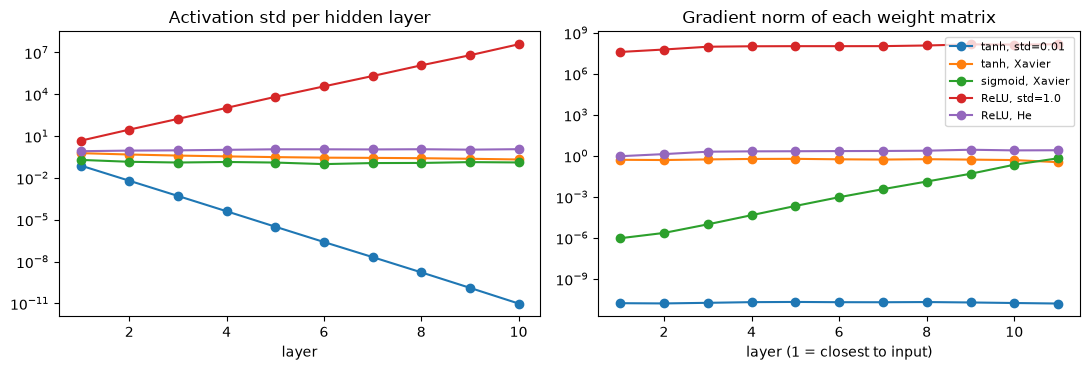

tanh + std=0.01 : activations shrink to std 1e-11 by layer 10; largest ‖dW‖ is 2e-11 → the signal dies in the forward pass, so every gradient vanishes.
sigmoid + Xavier: first-layer ‖dW‖ is 1e-06× the last layer's → vanishing gradients: the early layers would barely learn.
ReLU + std=1.0  : activations grow ×5.9 per layer, loss 3e+08 → exploding activations and gradients.
tanh, Xavier    : first/last ‖dW‖ ratio 1.49 → every layer gets a useful gradient.
ReLU, He        : first/last ‖dW‖ ratio 0.37 → every layer gets a useful gradient.


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, (act_stds, grad_norms, _) in stats.items():
    axes[0].plot(range(1, 11), act_stds, marker="o", label=name)
    axes[1].plot(range(1, 12), grad_norms, marker="o", label=name)
axes[0].set(title="Activation std per hidden layer", xlabel="layer", yscale="log")
axes[1].set(title="Gradient norm of each weight matrix", xlabel="layer (1 = closest to input)", yscale="log")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

def first_over_last(name):
    grad_norms = stats[name][1]
    return grad_norms[0] / grad_norms[-1]


act_tiny, grads_tiny, _ = stats["tanh, std=0.01"]
print(f"tanh + std=0.01 : activations shrink to std {act_tiny[-1]:.0e} by layer 10; largest ‖dW‖ is {max(grads_tiny):.0e} → "
      + ("the signal dies in the forward pass, so every gradient vanishes." if max(grads_tiny) < 1e-6 else "no vanishing here."))
ratio_sig = first_over_last("sigmoid, Xavier")
print(f"sigmoid + Xavier: first-layer ‖dW‖ is {ratio_sig:.0e}× the last layer's → "
      + ("vanishing gradients: the early layers would barely learn." if ratio_sig < 1e-3 else "no strong vanishing here."))
act_big = stats["ReLU, std=1.0"][0]
growth = (act_big[-1] / act_big[0]) ** (1 / 9)
print(f"ReLU + std=1.0  : activations grow ×{growth:.1f} per layer, loss {stats['ReLU, std=1.0'][2]:.0e} → "
      + ("exploding activations and gradients." if growth > 2 else "no explosion here."))
for name in ["tanh, Xavier", "ReLU, He"]:
    ratio = first_over_last(name)
    print(f"{name:16s}: first/last ‖dW‖ ratio {ratio:.2f} → "
          + ("every layer gets a useful gradient." if 0.1 < ratio < 10 else "imbalanced gradients."))

**What to notice:** with tiny weights the signal fades a little more at every layer, so *every* gradient ends up tiny; sigmoid's slope ≤ 0.25 makes the first layer's gradient orders of magnitude smaller than the last layer's even with Xavier; with std=1 and ReLU the activations grow several-fold per layer; **He + ReLU** and **Xavier + tanh** keep the signal and gradients in a healthy range.

Modern very deep networks add two more tools on top of good initialization: **normalization layers** (BatchNorm / LayerNorm) and **residual connections** ($x + f(x)$), which give gradients a shortcut path.

### ✍️ Your Turn

Compute the **He-normal** standard deviation for a ReLU layer with `fan_in = 64` (a float).

In [32]:
he_std_64 = None  # TODO
check("he_std", he_std_64, 0.17677670, hint="sqrt(2 / fan_in)")

⏳ he_std: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
he_std_64 = math.sqrt(2 / 64)
check("he_std", he_std_64, 0.17677670)
```

PyTorch's `nn.init.kaiming_normal_(w, nonlinearity="relu")` uses the same `sqrt(2 / fan_in)`.
</details>

> 💡 **Interview angle:** "What causes vanishing gradients and how do you fix them?" — repeated multiplication by small Jacobians (saturating activations, too-small weights). Fixes: ReLU-family activations, Xavier/He init, normalization layers, residual connections; for *exploding* gradients add **gradient clipping** and a lower learning rate.

## 11. Mini-Batching and SGD 🟢

Computing the gradient on **all** training data before every update (full-batch) is accurate but slow for big datasets. Using **one** example (pure stochastic gradient descent) is fast per update but very noisy. The practical middle ground is the **mini-batch**: shuffle the data every **epoch** (one full pass over the training set), cut it into batches of, say, 32, and update after each batch.

- **Updates per epoch** = `ceil(n_train / batch_size)`.
- The mini-batch gradient is a noisy but *unbiased* estimate of the full gradient; a little noise even helps escape poor regions.

In [33]:
def iterate_minibatches(n, batch_size, r):
    order = r.permutation(n)                      # new shuffle every epoch
    for start in range(0, n, batch_size):
        yield order[start:start + batch_size]


def evaluate(model, X, y):
    logits = model.forward(X, train=False)
    loss_value, _ = softmax_cross_entropy(logits, y)
    return float(loss_value), float((logits.argmax(axis=1) == y).mean())


rows = []
for batch_size in [1, 16, 128, len(X_train)]:
    r = np.random.default_rng(0)
    model = Sequential(Linear(64, 64, r), ReLU(), Linear(64, 10, r))
    start = time.perf_counter()
    for epoch in range(5):
        for idx in iterate_minibatches(len(X_train), batch_size, r):
            _, dlogits = softmax_cross_entropy(model.forward(X_train[idx]), y_train[idx])
            model.backward(dlogits)
            for p, g in model.params():
                p -= 0.05 * g                     # plain SGD step
    seconds = time.perf_counter() - start
    val_loss, val_acc = evaluate(model, X_val, y_val)
    rows.append((batch_size, math.ceil(len(X_train) / batch_size), seconds, val_loss, val_acc))
    print(f"batch {batch_size:5d} | {rows[-1][1]:5d} updates/epoch | 5 epochs in {seconds * 1000:6.1f} ms | "
          f"val loss {val_loss:.3f} | val acc {val_acc:.3f}")

best_row = max(rows, key=lambda row: row[4])
print(f"\nSame learning rate, same 5 epochs: batch {best_row[0]} reached the best val accuracy ({best_row[4]:.3f}); "
      f"full batch made only {rows[-1][1]} update(s) per epoch and reached {rows[-1][4]:.3f}.")

batch     1 |  1077 updates/epoch | 5 epochs in  132.9 ms | val loss 0.090 | val acc 0.975
batch    16 |    68 updates/epoch | 5 epochs in   10.5 ms | val loss 0.433 | val acc 0.897
batch   128 |     9 updates/epoch | 5 epochs in    3.0 ms | val loss 1.738 | val acc 0.572
batch  1077 |     1 updates/epoch | 5 epochs in    1.9 ms | val loss 2.320 | val acc 0.083

Same learning rate, same 5 epochs: batch 1 reached the best val accuracy (0.975); full batch made only 1 update(s) per epoch and reached 0.083.


Smaller batches make many more updates per epoch, so they learn more per pass over the data — but each epoch takes longer in wall-clock time because the hardware can't parallelize as much. On GPUs, larger batches (with a larger learning rate) usually win on wall-clock time; that trade-off is what "tuning the batch size" means.

### ✍️ Your Turn

A training set has **1,000** examples and the batch size is **64** (the last smaller batch is kept). How many parameter updates happen in **one epoch**? Store an integer.

In [34]:
updates_per_epoch = None  # TODO
check("updates_per_epoch", updates_per_epoch, 16, hint="math.ceil(1000 / 64)")

⏳ updates_per_epoch: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
updates_per_epoch = math.ceil(1000 / 64)
check("updates_per_epoch", updates_per_epoch, 16)
```

15 full batches of 64 (= 960 examples) plus one last batch of 40.
</details>

> 💡 **Interview angle:** "Why mini-batches instead of full-batch gradient descent?" — cheaper updates, many more steps per epoch, fits in memory, uses GPU parallelism, and gradient noise can help generalization. Be ready to mention that the learning rate often needs to grow with the batch size.

## 12. Optimizers From Scratch: SGD, Momentum, RMSProp, Adam 🟡

An **optimizer** decides how to turn a gradient into a parameter update.

| Optimizer | Update (per parameter) | Intuition |
|---|---|---|
| **SGD** | $\theta \leftarrow \theta - \eta g$ | step straight downhill |
| **Momentum** | $v \leftarrow \mu v + g$; $\theta \leftarrow \theta - \eta v$ | a heavy ball: keeps rolling, dampens zig-zags |
| **RMSProp** | $s \leftarrow \rho s + (1-\rho) g^2$; $\theta \leftarrow \theta - \eta\, g / (\sqrt{s} + \epsilon)$ | divide by recent gradient size → per-parameter step sizes |
| **Adam** | $m \leftarrow \beta_1 m + (1-\beta_1) g$; $v \leftarrow \beta_2 v + (1-\beta_2) g^2$; $\hat m = \frac{m}{1-\beta_1^t}$, $\hat v = \frac{v}{1-\beta_2^t}$; $\theta \leftarrow \theta - \eta\, \hat m / (\sqrt{\hat v} + \epsilon)$ | momentum + RMSProp + **bias correction** (m and v start at 0, so early averages are too small) |

These follow PyTorch's exact formulas (Section 🔧 proves it).

In [35]:
class SGD:
    def __init__(self, params, lr):
        self.params, self.lr = params, lr

    def step(self):
        for p, g in self.params:
            p -= self.lr * g


class Momentum:
    def __init__(self, params, lr, mu=0.9):
        self.params, self.lr, self.mu = params, lr, mu
        self.v = [np.zeros_like(p) for p, _ in params]

    def step(self):
        for (p, g), v in zip(self.params, self.v):
            v *= self.mu
            v += g
            p -= self.lr * v


class RMSProp:
    def __init__(self, params, lr=1e-3, rho=0.99, eps=1e-8):
        self.params, self.lr, self.rho, self.eps = params, lr, rho, eps
        self.s = [np.zeros_like(p) for p, _ in params]

    def step(self):
        for (p, g), s in zip(self.params, self.s):
            s *= self.rho
            s += (1 - self.rho) * g ** 2
            p -= self.lr * g / (np.sqrt(s) + self.eps)


class Adam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.params, self.lr, self.eps = params, lr, eps
        self.b1, self.b2 = betas
        self.m = [np.zeros_like(p) for p, _ in params]
        self.v = [np.zeros_like(p) for p, _ in params]
        self.t = 0

    def step(self):
        self.t += 1
        for (p, g), m, v in zip(self.params, self.m, self.v):
            m *= self.b1
            m += (1 - self.b1) * g
            v *= self.b2
            v += (1 - self.b2) * g ** 2
            m_hat = m / (1 - self.b1 ** self.t)
            v_hat = v / (1 - self.b2 ** self.t)
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

**A controlled picture first.** On a deliberately *synthetic* stretched bowl $f(w) = \tfrac12(w_1^2 + 20\,w_2^2)$ — steep in one direction, shallow in the other, like many real loss surfaces — watch how each optimizer moves.

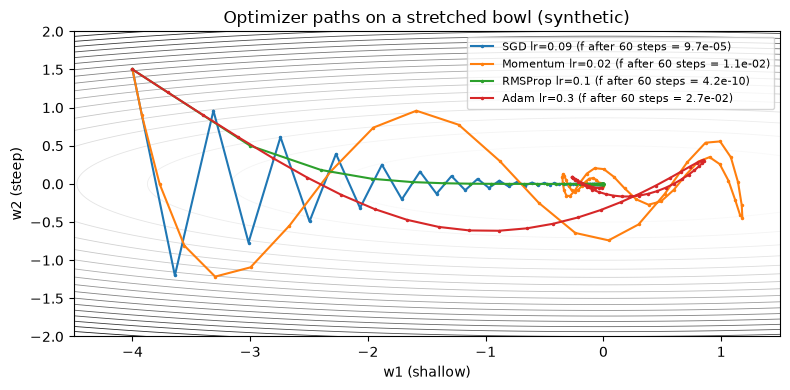

In [36]:
def run_on_bowl(make_opt, steps=60):
    w = np.array([-4.0, 1.5])
    g = np.zeros(2)
    opt = make_opt([(w, g)])
    path = [w.copy()]
    for _ in range(steps):
        g[...] = [w[0], 20 * w[1]]                # gradient of the bowl
        opt.step()
        path.append(w.copy())
    return np.array(path)


bowl = {
    "SGD lr=0.09": lambda ps: SGD(ps, lr=0.09),
    "Momentum lr=0.02": lambda ps: Momentum(ps, lr=0.02, mu=0.9),
    "RMSProp lr=0.1": lambda ps: RMSProp(ps, lr=0.1),
    "Adam lr=0.3": lambda ps: Adam(ps, lr=0.3),
}
g1, g2 = np.meshgrid(np.linspace(-4.5, 1.5, 200), np.linspace(-2, 2, 200))
fig, ax = plt.subplots(figsize=(8, 4))
ax.contour(g1, g2, 0.5 * (g1 ** 2 + 20 * g2 ** 2), levels=20, cmap="Greys", linewidths=0.6)
for name, make_opt in bowl.items():
    path = run_on_bowl(make_opt)
    final_f = 0.5 * (path[-1, 0] ** 2 + 20 * path[-1, 1] ** 2)
    ax.plot(path[:, 0], path[:, 1], marker=".", ms=3, label=f"{name} (f after 60 steps = {final_f:.1e})")
ax.set(title="Optimizer paths on a stretched bowl (synthetic)", xlabel="w1 (shallow)", ylabel="w2 (steep)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Now on real data.** Same 64→64→10 network, same initial weights, same mini-batches (size 32), 20 epochs, each optimizer with a commonly used default learning rate. (A fully fair comparison would tune each learning rate — see the stretch goals.)

SGD (lr=0.05)              | val loss after 1 epoch 1.892 → after 20 0.245 | val acc 0.956
Momentum (lr=0.05, μ=0.9)  | val loss after 1 epoch 0.637 → after 20 0.107 | val acc 0.956
RMSProp (lr=1e-3)          | val loss after 1 epoch 1.219 → after 20 0.164 | val acc 0.956


Adam (lr=1e-3)             | val loss after 1 epoch 1.961 → after 20 0.196 | val acc 0.953


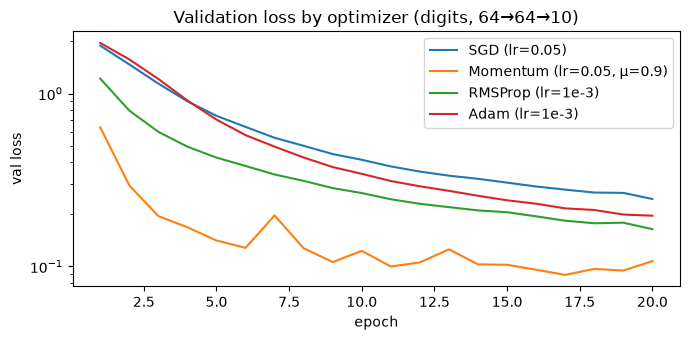

lowest val loss after 5 epochs: Momentum (lr=0.05, μ=0.9)


In [37]:
def train_epoch(model, optimizer, X, y, batch_size, r, weight_decay=0.0):
    total = 0.0
    for idx in iterate_minibatches(len(X), batch_size, r):
        loss_value, dlogits = softmax_cross_entropy(model.forward(X[idx], train=True), y[idx])
        model.backward(dlogits)
        if weight_decay:
            for p, g in model.params():
                if p.ndim == 2:                   # L2 on weights only, not biases
                    g += weight_decay * p
        optimizer.step()
        total += loss_value * len(idx)
    return total / len(X)


optimizer_setups = {
    "SGD (lr=0.05)": lambda ps: SGD(ps, lr=0.05),
    "Momentum (lr=0.05, μ=0.9)": lambda ps: Momentum(ps, lr=0.05),
    "RMSProp (lr=1e-3)": lambda ps: RMSProp(ps, lr=1e-3),
    "Adam (lr=1e-3)": lambda ps: Adam(ps, lr=1e-3),
}
curves = {}
for name, make_opt in optimizer_setups.items():
    r = np.random.default_rng(0)                  # identical init and batch order for every optimizer
    model = Sequential(Linear(64, 64, r), ReLU(), Linear(64, 10, r))
    opt = make_opt(model.params())
    history = []
    for epoch in range(20):
        train_epoch(model, opt, X_train, y_train, 32, r)
        history.append(evaluate(model, X_val, y_val))
    curves[name] = history
    print(f"{name:26s} | val loss after 1 epoch {history[0][0]:.3f} → after 20 {history[-1][0]:.3f} | val acc {history[-1][1]:.3f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
for name, history in curves.items():
    ax.plot(range(1, 21), [h[0] for h in history], label=name)
ax.set(title="Validation loss by optimizer (digits, 64→64→10)", xlabel="epoch", ylabel="val loss", yscale="log")
ax.legend()
plt.tight_layout()
plt.show()
fastest = min(curves, key=lambda k: curves[k][4][0])
print(f"lowest val loss after 5 epochs: {fastest}")

### ✍️ Your Turn

Do **one Adam step by hand** (with NumPy/Python arithmetic): parameter `p = 1.0`, gradient `g = 0.5`, `lr = 0.1`, `β1 = 0.9`, `β2 = 0.999`, `eps = 1e-8`, and this is step `t = 1` (so `m` and `v` start at 0). Store the new parameter value.

In [38]:
p_after_adam = None  # TODO
check("adam_step", p_after_adam, 0.9, hint="m = 0.05, v = 0.00025, then bias-correct both before the update.")

⏳ adam_step: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p, g, lr, b1, b2, eps, t = 1.0, 0.5, 0.1, 0.9, 0.999, 1e-8, 1
m = (1 - b1) * g                      # 0.05
v = (1 - b2) * g ** 2                 # 0.00025
m_hat, v_hat = m / (1 - b1 ** t), v / (1 - b2 ** t)   # 0.5, 0.25
p_after_adam = p - lr * m_hat / (math.sqrt(v_hat) + eps)
check("adam_step", p_after_adam, 0.9)
```

Bias correction makes `m_hat / sqrt(v_hat) = g / |g| = 1`, so Adam's first step has size ≈ `lr` **no matter how big or small the gradient is**. That scale-invariance is why Adam works "out of the box".
</details>

> 💡 **Interview angle:** "Adam vs SGD with momentum?" — Adam adapts a step size per parameter from gradient statistics and needs little tuning (the default for transformers, as AdamW); SGD+momentum uses less memory (one buffer instead of two) and, with a good learning-rate schedule, often generalizes as well or better on vision tasks.

## 13. Regularization: L2 and Inverted Dropout 🟡

**Overfitting** = the model memorizes the training set (train accuracy keeps rising) while getting worse on new data (validation loss rises). **Regularization** = anything that discourages memorizing.

- **L2 regularization**: add $\frac{\lambda}{2}\sum W^2$ to the loss, so the gradient gains $+\lambda W$ — it pulls weights toward 0 and prefers smoother functions. (With SGD this equals **weight decay**; with Adam it does not, which is why **AdamW** exists.)
- **Dropout**: during training, randomly zero each hidden unit with probability $p$, so the network can't rely on any single unit. **Inverted dropout** (used by PyTorch) scales the survivors by $\frac{1}{1-p}$ **during training**, so the expected activation stays the same and **evaluation needs no change at all** — dropout is simply switched off.

In [39]:
drop = Dropout(p=0.3, r=np.random.default_rng(0))
ones = np.ones((1000, 100))
train_out = drop.forward(ones, train=True)
print(f"train mode: fraction zeroed {np.mean(train_out == 0):.3f} | survivors equal {np.unique(train_out[train_out > 0])} "
      f"(= 1/(1-p) = {1 / 0.7:.4f}) | mean {train_out.mean():.3f}")
print(f"eval mode : identical to input? {np.array_equal(drop.forward(ones, train=False), ones)}")

# PyTorch's nn.Dropout behaves the same way
torch_drop = torch.nn.Dropout(p=0.3)
t_ones = torch.ones(1000, 100)
torch_drop.train()
t_out = torch_drop(t_ones)
assert torch.allclose(t_out[t_out > 0], torch.tensor(1 / 0.7))
torch_drop.eval()
assert torch.equal(torch_drop(t_ones), t_ones)
print("torch.nn.Dropout: scales by 1/(1-p) in train mode, identity in eval mode ✅")

train mode: fraction zeroed 0.299 | survivors equal [1.4286] (= 1/(1-p) = 1.4286) | mean 1.001
eval mode : identical to input? True
torch.nn.Dropout: scales by 1/(1-p) in train mode, identity in eval mode ✅


**Make a network overfit on purpose, then regularize it.** We train a big 64→256→256→10 network on only **200** training digits for 300 epochs with Adam, three ways, and watch the **validation loss** (it reacts to over-confidence long before accuracy does).

no regularization  | train acc 1.000 | val acc 0.936 | gap 0.064 | final val loss 0.264 (best 0.208 at epoch 36)


L2 (λ=1e-3)        | train acc 1.000 | val acc 0.925 | gap 0.075 | final val loss 0.207 (best 0.179 at epoch 195)


dropout (p=0.5)    | train acc 1.000 | val acc 0.928 | gap 0.072 | final val loss 0.246 (best 0.180 at epoch 139)


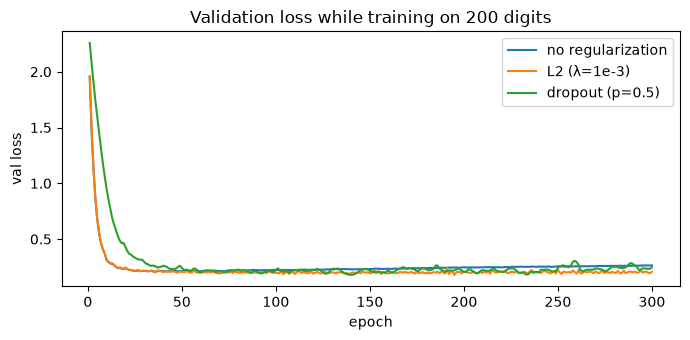

without regularization, val loss ended 0.057 above its best → overfitting: train accuracy is perfect while the model grows over-confident on validation mistakes.
L2 (λ=1e-3): best val loss 0.179 vs 0.208 without regularization; final 0.207 vs 0.264
dropout (p=0.5): best val loss 0.180 vs 0.208 without regularization; final 0.246 vs 0.264
Validation accuracy barely moves here — with only 200 examples, early stopping on validation loss is the other key tool.


In [40]:
X_small, y_small = X_train[:200], y_train[:200]
N_EPOCHS_REG = 300
reg_setups = {
    "no regularization": dict(p_drop=0.0, weight_decay=0.0),
    "L2 (λ=1e-3)": dict(p_drop=0.0, weight_decay=1e-3),
    "dropout (p=0.5)": dict(p_drop=0.5, weight_decay=0.0),
}
reg_results = {}
for name, cfg in reg_setups.items():
    r = np.random.default_rng(0)
    model = Sequential(Linear(64, 256, r), ReLU(), Dropout(cfg["p_drop"], r),
                       Linear(256, 256, r), ReLU(), Dropout(cfg["p_drop"], r),
                       Linear(256, 10, r))
    opt = Adam(model.params(), lr=1e-3)
    val_losses = []
    for epoch in range(N_EPOCHS_REG):
        train_epoch(model, opt, X_small, y_small, 32, r, weight_decay=cfg["weight_decay"])
        val_losses.append(evaluate(model, X_val, y_val)[0])
    train_loss, train_acc = evaluate(model, X_small, y_small)
    val_loss, val_acc = evaluate(model, X_val, y_val)
    reg_results[name] = dict(val_losses=val_losses, train_acc=train_acc, val_acc=val_acc, val_loss=val_loss)
    print(f"{name:18s} | train acc {train_acc:.3f} | val acc {val_acc:.3f} | gap {train_acc - val_acc:.3f} | "
          f"final val loss {val_loss:.3f} (best {min(val_losses):.3f} at epoch {int(np.argmin(val_losses)) + 1})")

fig, ax = plt.subplots(figsize=(7, 3.5))
for name, res in reg_results.items():
    ax.plot(range(1, N_EPOCHS_REG + 1), res["val_losses"], label=name)
ax.set(title="Validation loss while training on 200 digits", xlabel="epoch", ylabel="val loss")
ax.legend()
plt.tight_layout()
plt.show()

base = reg_results["no regularization"]
rise = base["val_loss"] - min(base["val_losses"])
print(f"without regularization, val loss ended {rise:.3f} above its best → "
      + ("overfitting: train accuracy is perfect while the model grows over-confident on validation mistakes."
         if rise > 0.01 else "little overfitting in this run."))
for name in ["L2 (λ=1e-3)", "dropout (p=0.5)"]:
    res = reg_results[name]
    print(f"{name}: best val loss {min(res['val_losses']):.3f} vs {min(base['val_losses']):.3f} without regularization; "
          f"final {res['val_loss']:.3f} vs {base['val_loss']:.3f}")
print("Validation accuracy barely moves here — with only 200 examples, early stopping on validation loss is the other key tool.")

### ✍️ Your Turn

Apply **inverted dropout** by hand: activations `x = [1, 2, 3, 4]`, drop probability `p = 0.25`, and the random keep-mask came out as `[1, 0, 1, 1]`. Compute the training-mode output.

In [41]:
x_drop = np.array([1.0, 2.0, 3.0, 4.0])
keep_mask = np.array([1.0, 0.0, 1.0, 1.0])
p_drop = 0.25
dropout_out = None  # TODO
check("inverted_dropout", dropout_out, [4 / 3, 0.0, 4.0, 16 / 3], hint="x * mask / (1 - p)")

⏳ inverted_dropout: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_drop = np.array([1.0, 2.0, 3.0, 4.0])
keep_mask = np.array([1.0, 0.0, 1.0, 1.0])
p_drop = 0.25
dropout_out = x_drop * keep_mask / (1 - p_drop)
check("inverted_dropout", dropout_out, [4 / 3, 0.0, 4.0, 16 / 3])
```

In **eval** mode the output would simply be `x_drop` — no mask and no scaling.
</details>

> 💡 **Interview angle:** "What does dropout do at inference time?" — nothing: with **inverted** dropout the 1/(1−p) scaling already happened during training, so `model.eval()` just turns it off. Saying "it scales activations by (1−p) at test time" describes the *original* 2014 formulation, not what PyTorch does.

## 🔧 Build It From Scratch

The #1 interview lever for this topic: *show that your from-scratch code matches a real framework exactly.* We already matched PyTorch for the scalar engine (Section 8). Now the vectorized network and the optimizers.

### 1) NumPy backprop == PyTorch autograd

In [42]:
r = np.random.default_rng(123)
ours = Sequential(Linear(64, 32, r), ReLU(), Linear(32, 10, r))
X_chk, y_chk = X_train[:16], y_train[:16]
loss_ours, dlogits = softmax_cross_entropy(ours.forward(X_chk), y_chk)
dX_ours = ours.backward(dlogits)

theirs = torch.nn.Sequential(torch.nn.Linear(64, 32), torch.nn.ReLU(), torch.nn.Linear(32, 10)).double()
with torch.no_grad():                               # copy our weights into the PyTorch model
    for t_layer, n_layer in [(theirs[0], ours.layers[0]), (theirs[2], ours.layers[2])]:
        t_layer.weight.copy_(torch.from_numpy(n_layer.W))
        t_layer.bias.copy_(torch.from_numpy(n_layer.b))

X_t = torch.from_numpy(X_chk).requires_grad_(True)
loss_theirs = F.cross_entropy(theirs(X_t), torch.from_numpy(y_chk))
loss_theirs.backward()

assert torch.allclose(loss_theirs, torch.tensor(loss_ours, dtype=torch.float64))
for t_layer, n_layer in [(theirs[0], ours.layers[0]), (theirs[2], ours.layers[2])]:
    assert torch.allclose(t_layer.weight.grad, torch.from_numpy(n_layer.dW))
    assert torch.allclose(t_layer.bias.grad, torch.from_numpy(n_layer.db))
assert torch.allclose(X_t.grad, torch.from_numpy(dX_ours))
print(f"loss {loss_ours:.6f} — weight, bias, and input gradients all match torch autograd ✅")

loss 2.539198 — weight, bias, and input gradients all match torch autograd ✅


### 2) Our optimizers == `torch.optim`

Feed the same sequence of random gradients to our optimizer and to PyTorch's, then compare the parameters after 25 steps.

In [43]:
def compare_optimizer(make_ours, make_torch, steps=25, seed=0):
    r = np.random.default_rng(seed)
    p_np = r.normal(size=(3, 4))
    g_np = np.zeros_like(p_np)
    p_t = torch.nn.Parameter(torch.from_numpy(p_np.copy()))
    opt_np, opt_t = make_ours([(p_np, g_np)]), make_torch([p_t])
    for _ in range(steps):
        g = r.normal(size=(3, 4))
        g_np[...] = g
        opt_np.step()
        p_t.grad = torch.from_numpy(g.copy())
        opt_t.step()
    return torch.allclose(p_t.detach(), torch.from_numpy(p_np))


optimizer_pairs = {
    "SGD": (lambda ps: SGD(ps, lr=0.1), lambda ps: torch.optim.SGD(ps, lr=0.1)),
    "Momentum": (lambda ps: Momentum(ps, lr=0.1, mu=0.9), lambda ps: torch.optim.SGD(ps, lr=0.1, momentum=0.9)),
    "RMSProp": (lambda ps: RMSProp(ps, lr=0.01, rho=0.99, eps=1e-8), lambda ps: torch.optim.RMSprop(ps, lr=0.01, alpha=0.99, eps=1e-8)),
    "Adam": (lambda ps: Adam(ps, lr=0.01), lambda ps: torch.optim.Adam(ps, lr=0.01)),
}
for name, (make_ours, make_torch) in optimizer_pairs.items():
    matched = compare_optimizer(make_ours, make_torch)
    assert matched, name
    print(f"{name:9s} matches torch.optim after 25 steps ✅")

SGD       matches torch.optim after 25 steps ✅
Momentum  matches torch.optim after 25 steps ✅
RMSProp   matches torch.optim after 25 steps ✅
Adam      matches torch.optim after 25 steps ✅


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Softmax, then log, as two separate steps

In [44]:
big_logits, target = np.array([[1000.0, 0.0, -1000.0]]), np.array([1])
with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
    naive_probs = np.exp(big_logits) / np.exp(big_logits).sum()
    print("❌ naive -log(softmax):", -np.log(naive_probs[0, target[0]]))
print("✅ stable log-softmax  :", -log_softmax(big_logits)[0, target[0]])

❌ naive -log(softmax): inf
✅ stable log-softmax  : 1000.0


### ❌ Pitfall 2 — Initializing all weights to zero

Every hidden unit computes the same thing and receives the same gradient, so they stay identical forever (**symmetry**). With ReLU and zero weights, no gradient reaches the first layer at all.

In [45]:
for label, std in [("❌ zero init", 0.0), ("✅ He init  ", None)]:
    r = np.random.default_rng(0)
    model = Sequential(Linear(64, 64, r, std=std), ReLU(), Linear(64, 10, r, std=std))
    opt = Adam(model.params(), lr=1e-3)
    for epoch in range(10):
        train_epoch(model, opt, X_train, y_train, 32, r)
    distinct_units = len(np.unique(model.layers[0].W.round(8), axis=0))
    print(f"{label} | val acc {evaluate(model, X_val, y_val)[1]:.3f} | distinct hidden units in layer 1: {distinct_units} of 64")

❌ zero init | val acc 0.103 | distinct hidden units in layer 1: 1 of 64
✅ He init   | val acc 0.939 | distinct hidden units in layer 1: 64 of 64


### ❌ Pitfall 3 — Using `=` instead of `+=` when propagating gradients

A value used twice must receive gradient from both uses.

In [46]:
class ValueWithBug(Value):
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = ValueWithBug(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad = out.grad                     # ❌ overwrites instead of accumulating
            other.grad = out.grad
        out._backward = _backward
        return out


a_bug = ValueWithBug(3.0)
(a_bug + a_bug).backward()
a_ok = Value(3.0)
(a_ok + a_ok).backward()
print(f"d(a + a)/da should be 2 → ❌ with '=': {a_bug.grad} | ✅ with '+=': {a_ok.grad}")

d(a + a)/da should be 2 → ❌ with '=': 1.0 | ✅ with '+=': 2.0


### ❌ Pitfall 4 — Leaving dropout on when evaluating

In [47]:
r = np.random.default_rng(0)
drop_model = Sequential(Linear(64, 128, r), ReLU(), Dropout(0.5, r), Linear(128, 10, r))
opt = Adam(drop_model.params(), lr=1e-3)
for epoch in range(10):
    train_epoch(drop_model, opt, X_train, y_train, 32, r)

pred_a = drop_model.forward(X_val, train=True).argmax(1)
pred_b = drop_model.forward(X_val, train=True).argmax(1)
print(f"❌ dropout on : {np.mean(pred_a != pred_b):.1%} of val predictions change between two identical calls | "
      f"val acc {np.mean(pred_a == y_val):.3f}")
pred_c = drop_model.forward(X_val, train=False).argmax(1)
pred_d = drop_model.forward(X_val, train=False).argmax(1)
print(f"✅ dropout off: {np.mean(pred_c != pred_d):.1%} change | val acc {np.mean(pred_c == y_val):.3f}")

❌ dropout on : 17.5% of val predictions change between two identical calls | val acc 0.861
✅ dropout off: 0.0% change | val acc 0.939


### ❌ Pitfall 5 — Gradient checking in float32

In [48]:
def float_model(dtype):
    model = Sequential(Linear(64, 32, np.random.default_rng(5)), Tanh(), Linear(32, 10, np.random.default_rng(6)))
    for layer in model.layers[0::2]:
        layer.W, layer.b = layer.W.astype(dtype), layer.b.astype(dtype)
        layer.dW, layer.db = np.zeros_like(layer.W), np.zeros_like(layer.b)
    return model


for label, dtype in [("❌ float32", np.float32), ("✅ float64", np.float64)]:
    model = float_model(dtype)
    X_d = X_batch.astype(dtype)
    _, dlogits = softmax_cross_entropy(model.forward(X_d), y_batch)
    model.backward(dlogits)
    worst = gradient_check(lambda: softmax_cross_entropy(model.forward(X_d), y_batch)[0], model.params())
    print(f"{label}: worst relative error {worst:.1e}" + ("  ← looks like a bug, but it's only rounding" if worst > 1e-4 else ""))

❌ float32: worst relative error 1.0e+00  ← looks like a bug, but it's only rounding
✅ float64: worst relative error 6.9e-09


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Leaky ReLU and its gradient
**Leaky ReLU** is `z` for `z > 0` and `alpha * z` otherwise (with `alpha = 0.01`), so negative units still pass a little gradient. Compute `leaky_out` and its derivative `leaky_grad` for `z = [-2.0, 0.5, 3.0]`.

In [49]:
z_leaky = np.array([-2.0, 0.5, 3.0])
alpha = 0.01
leaky_out = None   # TODO
leaky_grad = None  # TODO
check("leaky_out", leaky_out, [-0.02, 0.5, 3.0], hint="np.where(z > 0, z, alpha * z)")
check("leaky_grad", leaky_grad, [0.01, 1.0, 1.0], hint="np.where(z > 0, 1.0, alpha)")

⏳ leaky_out: not attempted yet — replace None with your answer.
⏳ leaky_grad: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
z_leaky = np.array([-2.0, 0.5, 3.0])
alpha = 0.01
leaky_out = np.where(z_leaky > 0, z_leaky, alpha * z_leaky)
leaky_grad = np.where(z_leaky > 0, 1.0, alpha)
check("leaky_out", leaky_out, [-0.02, 0.5, 3.0])
check("leaky_grad", leaky_grad, [0.01, 1.0, 1.0])
```
</details>

### 🟢 Exercise 2 — Softmax cross-entropy gradient for a batch
Compute the gradient of the **mean** cross-entropy with respect to `logits` (shape `(2, 3)`) for labels `[0, 2]`, using the `p − y` rule. The checker uses PyTorch autograd as the reference.

In [50]:
logits_b = np.array([[2.0, 1.0, 0.0],
                     [0.0, 0.0, 0.0]])
labels_b = np.array([0, 2])
dlogits_b = None  # TODO

_ref = torch.tensor(logits_b, requires_grad=True)
F.cross_entropy(_ref, torch.from_numpy(labels_b)).backward()
check("ce_batch_grad", dlogits_b, _ref.grad.numpy(), hint="(softmax(logits_b) - np.eye(3)[labels_b]) / len(labels_b)")

⏳ ce_batch_grad: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
logits_b = np.array([[2.0, 1.0, 0.0], [0.0, 0.0, 0.0]])
labels_b = np.array([0, 2])
dlogits_b = (softmax(logits_b) - np.eye(3)[labels_b]) / len(labels_b)

_ref = torch.tensor(logits_b, requires_grad=True)
F.cross_entropy(_ref, torch.from_numpy(labels_b)).backward()
check("ce_batch_grad", dlogits_b, _ref.grad.numpy())
```

Forgetting the `/ len(labels_b)` is the most common mistake: the loss is a *mean*, so every example's gradient is divided by the batch size.
</details>

### 🟢 Exercise 3 — Three steps of SGD with momentum
Minimize $f(w) = w^2$ (gradient $2w$) starting from `w = 1.0` with PyTorch-style momentum: `v = mu * v + g; w = w - lr * v`, using `lr = 0.1`, `mu = 0.9`, `v = 0`. Store `w` after **3** steps.

In [51]:
w_momentum = None  # TODO: loop 3 times
check("momentum_3_steps", w_momentum, 0.062, hint="Step 1: v=2.0, w=0.8. Step 2: g=1.6, v=3.4, w=0.46. One more!")

⏳ momentum_3_steps: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
w, v, lr, mu = 1.0, 0.0, 0.1, 0.9
for _ in range(3):
    g = 2 * w
    v = mu * v + g
    w = w - lr * v
w_momentum = w
check("momentum_3_steps", w_momentum, 0.062)
```

Plain SGD would be at `0.512` after 3 steps (`w ← 0.8·w`); momentum has already moved much further.
</details>

### 🟡 Exercise 4 — Backward pass of a linear layer
Given input `X (4, 3)`, weight `W (2, 3)`, and upstream gradient `dout (4, 2)` for `out = X @ W.T + b`, return `dX`, `dW`, `db` from `linear_backward`. The checker compares with PyTorch autograd.

In [52]:
def linear_backward(dout, X, W):
    dX, dW, db = None, None, None  # TODO
    return dX, dW, db


_r = np.random.default_rng(11)
X_lb, W_lb, b_lb, dout_lb = _r.normal(size=(4, 3)), _r.normal(size=(2, 3)), _r.normal(size=2), _r.normal(size=(4, 2))
_X, _W, _b = (torch.tensor(a, requires_grad=True) for a in (X_lb, W_lb, b_lb))
((_X @ _W.T + _b) * torch.from_numpy(dout_lb)).sum().backward()      # a loss whose gradient w.r.t. out is dout

dX_lb, dW_lb, db_lb = linear_backward(dout_lb, X_lb, W_lb)
check("dX", dX_lb, _X.grad.numpy(), hint="dX = dout @ W, shape (4, 3)")
check("dW", dW_lb, _W.grad.numpy(), hint="dW = dout.T @ X, shape (2, 3)")
check("db", db_lb, _b.grad.numpy(), hint="db = dout summed over the batch axis")

⏳ dX: not attempted yet — replace None with your answer.
⏳ dW: not attempted yet — replace None with your answer.
⏳ db: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def linear_backward(dout, X, W):
    return dout @ W, dout.T @ X, dout.sum(axis=0)

_r = np.random.default_rng(11)
X_lb, W_lb, b_lb, dout_lb = _r.normal(size=(4, 3)), _r.normal(size=(2, 3)), _r.normal(size=2), _r.normal(size=(4, 2))
_X, _W, _b = (torch.tensor(a, requires_grad=True) for a in (X_lb, W_lb, b_lb))
((_X @ _W.T + _b) * torch.from_numpy(dout_lb)).sum().backward()

dX_lb, dW_lb, db_lb = linear_backward(dout_lb, X_lb, W_lb)
check("dX", dX_lb, _X.grad.numpy())
check("dW", dW_lb, _W.grad.numpy())
check("db", db_lb, _b.grad.numpy())
```

The trick `(out * dout).sum().backward()` injects any upstream gradient you like — handy for testing a single layer.
</details>

### 🟡 Exercise 5 — Early stopping logic
Validation losses per epoch are given. With **patience = 3** (stop once 3 epochs in a row fail to beat the best loss so far), return `stop_epoch` (the 0-based epoch where training stops) and `best_epoch` (the epoch whose weights you keep).

In [53]:
val_history = [0.90, 0.70, 0.60, 0.62, 0.61, 0.63, 0.64, 0.50]
patience = 3


def early_stopping(losses, patience):
    stop_epoch, best_epoch = None, None  # TODO: loop over losses
    return stop_epoch, best_epoch


result_es = early_stopping(val_history, patience)
check("early_stopping", None if result_es[0] is None else result_es, (5, 2),
      hint="Track best loss and the epoch it happened; stop when epoch - best_epoch == patience.")

⏳ early_stopping: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
val_history = [0.90, 0.70, 0.60, 0.62, 0.61, 0.63, 0.64, 0.50]
patience = 3

def early_stopping(losses, patience):
    best_loss, best_epoch = float("inf"), 0
    for epoch, loss in enumerate(losses):
        if loss < best_loss:
            best_loss, best_epoch = loss, epoch
        elif epoch - best_epoch >= patience:
            return epoch, best_epoch
    return len(losses) - 1, best_epoch

result_es = early_stopping(val_history, patience)
check("early_stopping", result_es, (5, 2))
```

Training stops at epoch 5 and never sees the 0.50 at epoch 7 — the price of early stopping. A larger patience trades compute for the chance of a later improvement.
</details>

### 🔴 Exercise 6 — Backprop through a 2-layer tanh network with MSE (interview classic)
Network: `H = tanh(X @ W1.T + b1)`, `Y_hat = H @ W2.T + b2`, loss `L = mean((Y_hat - Y) ** 2)` (mean over **all** entries). Implement `tanh_mlp_grads` returning a dict with gradients for `W1`, `b1`, `W2`, `b2`. The checker compares with PyTorch autograd.

In [54]:
def tanh_mlp_grads(X, Y, W1, b1, W2, b2):
    return None  # TODO: forward, then backward; return {"W1": ..., "b1": ..., "W2": ..., "b2": ...}


_r = np.random.default_rng(21)
X_m, Y_m = _r.normal(size=(8, 5)), _r.normal(size=(8, 2))
W1_m, b1_m, W2_m, b2_m = _r.normal(size=(6, 5)), _r.normal(size=6), _r.normal(size=(2, 6)), _r.normal(size=2)
_t = {k: torch.tensor(v, requires_grad=True) for k, v in dict(W1=W1_m, b1=b1_m, W2=W2_m, b2=b2_m).items()}
_pred = torch.tanh(torch.from_numpy(X_m) @ _t["W1"].T + _t["b1"]) @ _t["W2"].T + _t["b2"]
((_pred - torch.from_numpy(Y_m)) ** 2).mean().backward()

grads_m = tanh_mlp_grads(X_m, Y_m, W1_m, b1_m, W2_m, b2_m)
for key in ["W1", "b1", "W2", "b2"]:
    check(f"grad_{key}", None if grads_m is None else grads_m[key], _t[key].grad.numpy(),
          hint="dY_hat = 2 (Y_hat − Y) / Y.size; then linear backward, tanh backward (1 − H²), linear backward.")

⏳ grad_W1: not attempted yet — replace None with your answer.
⏳ grad_b1: not attempted yet — replace None with your answer.
⏳ grad_W2: not attempted yet — replace None with your answer.
⏳ grad_b2: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def tanh_mlp_grads(X, Y, W1, b1, W2, b2):
    H = np.tanh(X @ W1.T + b1)                  # forward
    Y_hat = H @ W2.T + b2
    dY_hat = 2 * (Y_hat - Y) / Y.size           # mean over every entry
    dW2, db2 = dY_hat.T @ H, dY_hat.sum(axis=0)
    dH = dY_hat @ W2
    dZ1 = dH * (1 - H ** 2)                     # tanh backward
    dW1, db1 = dZ1.T @ X, dZ1.sum(axis=0)
    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

_r = np.random.default_rng(21)
X_m, Y_m = _r.normal(size=(8, 5)), _r.normal(size=(8, 2))
W1_m, b1_m, W2_m, b2_m = _r.normal(size=(6, 5)), _r.normal(size=6), _r.normal(size=(2, 6)), _r.normal(size=2)
_t = {k: torch.tensor(v, requires_grad=True) for k, v in dict(W1=W1_m, b1=b1_m, W2=W2_m, b2=b2_m).items()}
_pred = torch.tanh(torch.from_numpy(X_m) @ _t["W1"].T + _t["b1"]) @ _t["W2"].T + _t["b2"]
((_pred - torch.from_numpy(Y_m)) ** 2).mean().backward()

grads_m = tanh_mlp_grads(X_m, Y_m, W1_m, b1_m, W2_m, b2_m)
for key in ["W1", "b1", "W2", "b2"]:
    check(f"grad_{key}", grads_m[key], _t[key].grad.numpy())
```

In an interview, say the shapes out loud at each line — e.g. "`dW2` must be `(2, 6)` like `W2`, so it's `dY_hat.T @ H`".
</details>

## 🚀 Mini Project: NumPy Digit Classifier vs PyTorch

**Goal:** build a digit classifier in **pure NumPy** — our own layers, backprop, Adam, dropout — train it with **early stopping on the validation set**, report accuracy on the untouched **test set once**, and compare it with the equivalent model written in **PyTorch**.

**Steps:** recap the data split → train the NumPy MLP with early stopping → learning curves → test-set evaluation and baselines → the same model in PyTorch → compare.

### Step 1 — The data split (done once in Section 4)

Train is used for weight updates, validation for early stopping, test only at the very end. Pixels were scaled by the constant 16, so no statistics leak from validation or test into training.

In [55]:
for name, (Xs, ys) in {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}.items():
    print(f"{name:5s} {Xs.shape} | class counts {np.bincount(ys)}")

train (1077, 64) | class counts [106 109 107 109 109 109 109 107 104 108]
val   (360, 64) | class counts [36 37 35 37 36 36 36 36 35 36]
test  (360, 64) | class counts [36 36 35 37 36 37 36 36 35 36]


### Step 2 — Train the NumPy MLP with Adam, dropout, and early stopping

In [56]:
def fit_numpy_mlp(hidden=128, p_drop=0.2, lr=1e-3, batch_size=32, max_epochs=300, patience=20, seed=0):
    r = np.random.default_rng(seed)
    model = Sequential(Linear(64, hidden, r), ReLU(), Dropout(p_drop, r), Linear(hidden, 10, r))
    opt = Adam(model.params(), lr=lr)
    history, best_loss, best_epoch, best_weights = [], np.inf, 0, None
    for epoch in range(max_epochs):
        train_loss = train_epoch(model, opt, X_train, y_train, batch_size, r)
        val_loss, val_acc = evaluate(model, X_val, y_val)
        history.append((train_loss, val_loss, val_acc))
        if val_loss < best_loss:
            best_loss, best_epoch = val_loss, epoch
            best_weights = [p.copy() for p, _ in model.params()]
        elif epoch - best_epoch >= patience:
            break
    for (p, _), saved in zip(model.params(), best_weights):   # restore the best checkpoint in place
        p[...] = saved
    return model, np.array(history), best_epoch


start = time.perf_counter()
np_model, np_history, np_best_epoch = fit_numpy_mlp()
np_seconds = time.perf_counter() - start
print(f"stopped after {len(np_history)} epochs ({np_seconds:.1f} s); best epoch {np_best_epoch + 1} "
      f"with val loss {np_history[np_best_epoch, 1]:.4f} and val acc {np_history[np_best_epoch, 2]:.3f}")

stopped after 192 epochs (0.6 s); best epoch 172 with val loss 0.0300 and val acc 0.986


### Step 3 — Learning curves

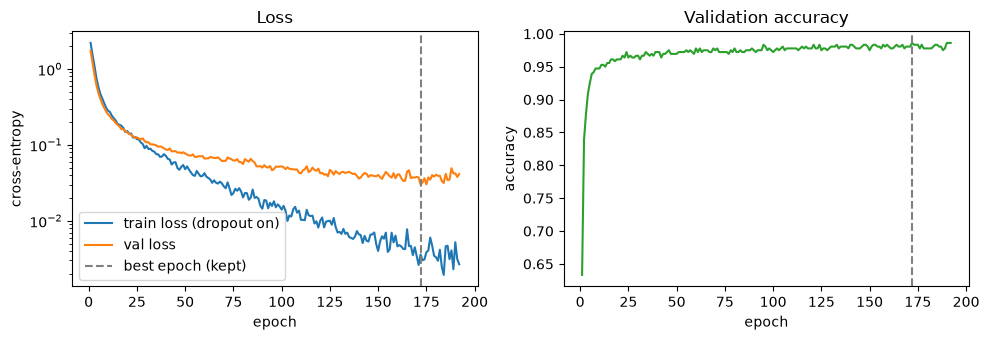

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
epochs_axis = np.arange(1, len(np_history) + 1)
axes[0].plot(epochs_axis, np_history[:, 0], label="train loss (dropout on)")
axes[0].plot(epochs_axis, np_history[:, 1], label="val loss")
axes[0].axvline(np_best_epoch + 1, color="gray", ls="--", label="best epoch (kept)")
axes[0].set(xlabel="epoch", ylabel="cross-entropy", yscale="log", title="Loss")
axes[1].plot(epochs_axis, np_history[:, 2], color="tab:green")
axes[1].axvline(np_best_epoch + 1, color="gray", ls="--")
axes[1].set(xlabel="epoch", ylabel="accuracy", title="Validation accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()

### Step 4 — Evaluate on the test set (once) and compare with baselines

majority-class baseline : 0.100
logistic regression     : 0.956
NumPy MLP (ours)        : 0.986  (test loss 0.056)
per-class test accuracy: {0: 1.0, 1: 0.944, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 0.943, 9: 0.972}
most common confusion: true 1 predicted as 8 (2 times)


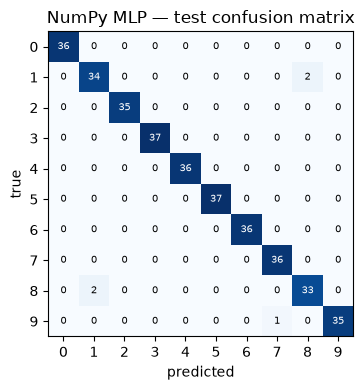

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

np_test_loss, np_test_acc = evaluate(np_model, X_test, y_test)
majority_acc = float(np.mean(y_test == np.bincount(y_train).argmax()))
logreg = LogisticRegression(max_iter=2000).fit(X_train, y_train)
logreg_acc = logreg.score(X_test, y_test)

print(f"majority-class baseline : {majority_acc:.3f}")
print(f"logistic regression     : {logreg_acc:.3f}")
print(f"NumPy MLP (ours)        : {np_test_acc:.3f}  (test loss {np_test_loss:.3f})")

np_test_pred = np_model.forward(X_test, train=False).argmax(axis=1)
cm = confusion_matrix(y_test, np_test_pred)
per_class = cm.diagonal() / cm.sum(axis=1)
print("per-class test accuracy:", {d: round(float(a), 3) for d, a in enumerate(per_class)})
off_diag = cm - np.diag(np.diag(cm))
true_d, pred_d = np.unravel_index(off_diag.argmax(), cm.shape)
print(f"most common confusion: true {true_d} predicted as {pred_d} ({off_diag.max()} times)")

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7, color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set(xticks=range(10), yticks=range(10), xlabel="predicted", ylabel="true", title="NumPy MLP — test confusion matrix")
plt.tight_layout()
plt.show()

### Step 5 — The same model in PyTorch

Same architecture (64→128→ReLU→Dropout(0.2)→10), He-normal init with zero biases, Adam(lr=1e-3), batch size 32, and the same early-stopping rule. Note `model.train()` / `model.eval()` switch dropout on and off — the equivalent of our `train=True/False` flag.

In [59]:
def fit_torch_mlp(hidden=128, p_drop=0.2, lr=1e-3, batch_size=32, max_epochs=300, patience=20, seed=0):
    torch.manual_seed(seed)
    model = torch.nn.Sequential(torch.nn.Linear(64, hidden), torch.nn.ReLU(), torch.nn.Dropout(p_drop), torch.nn.Linear(hidden, 10))
    for layer in (model[0], model[3]):
        torch.nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
        torch.nn.init.zeros_(layer.bias)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xtr, ytr = torch.tensor(X_train, dtype=torch.float32), torch.from_numpy(y_train)
    Xva, yva = torch.tensor(X_val, dtype=torch.float32), torch.from_numpy(y_val)
    best_loss, best_epoch, best_state, n_epochs = float("inf"), 0, None, 0
    for epoch in range(max_epochs):
        model.train()
        for idx in torch.randperm(len(Xtr)).split(batch_size):
            loss = F.cross_entropy(model(Xtr[idx]), ytr[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            val_loss = F.cross_entropy(model(Xva), yva).item()
        n_epochs = epoch + 1
        if val_loss < best_loss:
            best_loss, best_epoch = val_loss, epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        elif epoch - best_epoch >= patience:
            break
    model.load_state_dict(best_state)
    model.eval()
    return model, n_epochs, best_epoch


start = time.perf_counter()
torch_model, torch_epochs, torch_best_epoch = fit_torch_mlp()
torch_seconds = time.perf_counter() - start
with torch.no_grad():
    torch_test_logits = torch_model(torch.tensor(X_test, dtype=torch.float32))
torch_test_acc = (torch_test_logits.argmax(1).numpy() == y_test).mean()
print(f"PyTorch MLP: stopped after {torch_epochs} epochs ({torch_seconds:.1f} s), best epoch {torch_best_epoch + 1}")

PyTorch MLP: stopped after 156 epochs (1.0 s), best epoch 136


### Step 6 — Compare

In [60]:
print(f"{'model':22s} {'test acc':>9s} {'epochs':>7s} {'seconds':>8s}")
print(f"{'logistic regression':22s} {logreg_acc:9.3f} {'-':>7s} {'-':>8s}")
print(f"{'NumPy MLP (ours)':22s} {np_test_acc:9.3f} {len(np_history):7d} {np_seconds:8.1f}")
print(f"{'PyTorch MLP':22s} {torch_test_acc:9.3f} {torch_epochs:7d} {torch_seconds:8.1f}")

gap = abs(np_test_acc - torch_test_acc)
n_test = len(y_test)
print(f"\nThe two MLPs differ by {gap * 100:.1f} percentage points (= {round(gap * n_test)} of {n_test} test images).")
if gap <= 0.02:
    print("→ Within run-to-run noise: our from-scratch implementation behaves like the framework version.")
else:
    print("→ A noticeable gap — try several seeds before concluding one implementation is better.")
print(f"Both {'beat' if min(np_test_acc, torch_test_acc) > logreg_acc else 'do not clearly beat'} logistic regression ({logreg_acc:.3f}).")

model                   test acc  epochs  seconds
logistic regression        0.956       -        -
NumPy MLP (ours)           0.986     192      0.6
PyTorch MLP                0.983     156      1.0

The two MLPs differ by 0.3 percentage points (= 1 of 360 test images).
→ Within run-to-run noise: our from-scratch implementation behaves like the framework version.
Both beat logistic regression (0.956).


**Stretch goals**
1. Run both MLPs with **5 different seeds** and report mean ± std test accuracy — is the gap real?
2. **Tune** the learning rate and hidden size on the *validation* set (never on test) with a small grid search.
3. Add **L2 / weight decay** to the NumPy model and implement **AdamW** (decay applied directly to the weights, not through the gradient). Compare with `torch.optim.AdamW`.
4. Implement **BatchNorm** forward/backward as a layer and gradient-check it.

### 🗣️ How to talk about this in an interview
- "I implemented an MLP in pure NumPy — linear, ReLU and inverted-dropout layers with hand-derived backward passes — and verified every gradient against **finite differences** and **PyTorch autograd** with `torch.allclose`."
- "Training used mini-batch **Adam** written from scratch (checked against `torch.optim.Adam`), He initialization, and **early stopping on a validation split**; I restored the best checkpoint and evaluated on the test set only once."
- "On a held-out test set of 360 digits, the NumPy model and an equivalent PyTorch model landed within run-to-run noise of each other, and both are compared against logistic regression and a majority baseline."
- "Debugging habits I used: a loss ≈ ln(10) sanity check at initialization, gradient checks in float64, and learning curves to spot overfitting."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why do neural networks need non-linear activation functions?**

<details><summary>Show answer</summary>

- **30-second answer:** Without them, stacked linear layers collapse into a single linear layer ($W_2(W_1x+b_1)+b_2 = Wx+b$), so depth adds nothing. Non-linearities let the network represent curved decision boundaries and, with enough units, approximate essentially any continuous function (the universal approximation theorem).
- **Go deeper:** Universal approximation says a wide enough single hidden layer *can* represent a function; it says nothing about learning it efficiently. Depth gives more efficient, hierarchical representations in practice.
- **❌ Common wrong answer:** "Activations normalize the outputs to a range" — that's a side effect of some (sigmoid/tanh), not the purpose; ReLU is unbounded.

</details>

**Q2. Why is ReLU usually preferred over sigmoid or tanh in hidden layers? What are its downsides?**

<details><summary>Show answer</summary>

- **30-second answer:** ReLU's gradient is 1 for positive inputs, so it doesn't saturate and gradients don't shrink layer after layer; it's also cheap and gives sparse activations. Sigmoid's derivative is at most 0.25 and near 0 for large |z|.
- **Go deeper:** Downsides: **dying ReLU** (units whose input is always negative get zero gradient forever — often from a too-high learning rate), non-zero-centred outputs, and a kink at 0. Variants: Leaky ReLU, ELU, and **GELU** / **SwiGLU** used in modern transformers.
- **❌ Common wrong answer:** "ReLU has no gradient problems at all" — negative inputs have exactly zero gradient.

</details>

**Q3. What are vanishing and exploding gradients, and how do you fix them?**

<details><summary>Show answer</summary>

- **30-second answer:** Backprop multiplies per-layer factors; if they're consistently < 1 the early-layer gradients vanish (those layers stop learning), if > 1 they explode (loss spikes, `nan`). Fixes: ReLU-family activations, Xavier/He initialization, normalization layers (BatchNorm/LayerNorm), residual connections, and gradient clipping for explosions.
- **Go deeper:** In RNNs the same weight matrix is multiplied at every time step, which is why LSTMs/GRUs add gated, additive paths. Monitor per-layer gradient norms to diagnose — as in Section 10.
- **❌ Common wrong answer:** "Use a bigger learning rate to fix vanishing gradients" — it scales every layer equally and usually makes the later layers diverge.

</details>

**Q4. Why not initialize all weights to zero? What do Xavier and He initialization do?**

<details><summary>Show answer</summary>

- **30-second answer:** With identical weights every hidden unit computes the same output and receives the same gradient, so they stay identical (symmetry is never broken). Xavier (std $\sqrt{2/(\text{fan\_in}+\text{fan\_out})}$) and He (std $\sqrt{2/\text{fan\_in}}$) pick a random scale that keeps activation and gradient variance roughly constant across layers; He's extra factor 2 compensates for ReLU zeroing half its inputs.
- **Go deeper:** Biases *can* start at zero because the random weights already break symmetry. PyTorch's `nn.Linear` default is a Kaiming-uniform variant; transformers often use small normal init (e.g. std 0.02) plus residual scaling.
- **❌ Common wrong answer:** "Any small random numbers like std=0.01 work" — in deep networks that makes activations and gradients vanish.

</details>

**Q5. How does Adam work, and when might you choose SGD with momentum instead?**

<details><summary>Show answer</summary>

- **30-second answer:** Adam keeps an exponential moving average of gradients (momentum, $m$) and of squared gradients ($v$), bias-corrects both, and updates each parameter by $\eta\,\hat m/(\sqrt{\hat v}+\epsilon)$ — a per-parameter adaptive step. It converges fast with little tuning. SGD+momentum uses half the optimizer memory and, with a tuned learning-rate schedule, often generalizes as well or better on image classification.
- **Go deeper:** With Adam, an L2 penalty added to the gradient gets divided by $\sqrt{\hat v}$, so parameters with large gradients are regularized less. **AdamW** decouples weight decay (applies $\theta \leftarrow \theta - \eta\lambda\theta$ directly) and is the standard for transformers. Adam stores two extra tensors per parameter — relevant when sizing GPU memory for large models.
- **❌ Common wrong answer:** "Adam is always better than SGD" or "weight decay and L2 regularization are the same thing in Adam."

</details>

**Q6. How does dropout behave during training versus evaluation?**

<details><summary>Show answer</summary>

- **30-second answer:** In training, each unit is zeroed with probability $p$ and the survivors are scaled by $1/(1-p)$ (**inverted dropout**), so the expected activation is unchanged. At evaluation dropout is turned off entirely — identity, no scaling — which is what `model.eval()` does in PyTorch.
- **Go deeper:** The original paper (Srivastava et al., 2014) instead kept activations unscaled in training and multiplied weights by the keep probability at test time; inverted dropout moves that cost to training so inference is untouched. Dropout can be seen as training an ensemble of sub-networks that share weights.
- **❌ Common wrong answer:** "At test time PyTorch multiplies activations by (1 − p)." It doesn't — the scaling happened during training.

</details>

**Q7. What is reverse-mode automatic differentiation, and why do deep-learning frameworks use it?**

<details><summary>Show answer</summary>

- **30-second answer:** The forward pass records a graph of elementary operations; the backward pass walks it in reverse topological order, multiplying upstream gradients by local derivatives (chain rule) and accumulating them. For a scalar loss and millions of parameters, one backward pass gives *all* the gradients at a cost of a small constant multiple of the forward pass.
- **Go deeper:** Forward-mode AD needs one pass per input dimension, which is great for few inputs/many outputs but terrible for neural nets. Reverse mode's price is memory: intermediate activations must be stored for the backward pass — hence **activation checkpointing** trades compute for memory.
- **❌ Common wrong answer:** "Autograd uses finite differences" or "it does symbolic differentiation of the whole formula."

</details>

### 💻 Coding

**Q8. Derive the backward pass for a linear layer `out = X @ W.T + b`.**

<details><summary>Show answer</summary>

- **30-second answer:** With upstream gradient `dout` of shape `(n, out)`: `dW = dout.T @ X` → `(out, in)`, `db = dout.sum(axis=0)` → `(out,)`, `dX = dout @ W` → `(n, in)`. Use the rule "a gradient has the shape of its variable" to place the transposes.
- **Go deeper:** The bias gradient sums over the batch because the same bias is added to every row (broadcasting in forward ⇒ summing in backward). The same rule extends to attention: every matrix multiply in forward becomes two matrix multiplies in backward.
- **❌ Common wrong answer:** Forgetting to sum `db` over the batch, or writing `dW = X.T @ dout`, which has shape `(in, out)` — the transpose of the right answer under PyTorch's weight convention.

</details>

**Q9. Derive the gradient of softmax followed by cross-entropy with respect to the logits.**

<details><summary>Show answer</summary>

- **30-second answer:** $L = -z_y + \log\sum_j e^{z_j}$, so $\partial L/\partial z_k = p_k - \mathbb{1}[k=y]$, i.e. **`p − y`** with one-hot `y`; divide by `n` for a batch mean.
- **Go deeper:** The softmax Jacobian alone is $\text{diag}(p) - pp^\top$, but combined with cross-entropy it simplifies beautifully. That's why frameworks fuse them: `nn.CrossEntropyLoss` takes raw logits and uses log-sum-exp, which is both faster and numerically stable.
- **❌ Common wrong answer:** Applying `softmax` before `nn.CrossEntropyLoss` (double softmax → weak, squashed gradients), or computing `log(softmax(z))` in two steps and getting `-inf`.

</details>

**Q10. How would you implement a gradient check, and what results would convince you?**

<details><summary>Show answer</summary>

- **30-second answer:** For a few random entries of each parameter, perturb by ±ε (≈1e-5), recompute the loss, and compare the centered difference $(L^+ - L^-)/2\varepsilon$ with the analytic gradient using relative error $|a-n|/(|a|+|n|)$. Use float64, turn off dropout and other randomness. Around 1e-7 or below is correct; above ~1e-3 is a bug.
- **Go deeper:** Centered differences have $O(\varepsilon^2)$ error versus $O(\varepsilon)$ one-sided. Too small an ε causes rounding error (worse in float32). Non-differentiable points (ReLU at 0, max-pooling ties) can produce isolated false alarms.
- **❌ Common wrong answer:** "Compare absolute differences with a fixed threshold" — tiny gradients always pass and huge ones always fail.

</details>

### 🐛 Debugging Scenarios

**Q11. Your 10-class classifier's loss sits at about 2.30 and never moves. What's going on?**

<details><summary>Show answer</summary>

- **30-second answer:** $2.30 = \ln 10$ is the loss of predicting a uniform distribution — the model isn't learning at all. Check that the optimizer actually steps the model's parameters, gradients are non-zero (not detached, not all dead ReLUs), the learning rate isn't tiny or huge, and inputs and labels are aligned.
- **Go deeper:** The fastest test is to **overfit a single small batch**: a correct pipeline drives its loss near 0 within a few hundred steps. Then print per-layer gradient norms to find where the signal stops.
- **❌ Common wrong answer:** "Train for more epochs" — a loss stuck exactly at ln(C) means no learning signal, not slow learning.

</details>

**Q12. Training accuracy is 100% but validation accuracy is 80% and validation loss is rising. Diagnose and fix.**

<details><summary>Show answer</summary>

- **30-second answer:** Overfitting: the model memorizes training data. Use early stopping on validation loss, add regularization (dropout, weight decay), augment or collect more data, or reduce model size.
- **Go deeper:** Look at learning curves: a growing train/val gap with rising val loss is overfitting; both losses high is underfitting (bigger model, train longer, less regularization). Validation *loss* often rises before validation *accuracy* drops, because the model becomes over-confident on the examples it gets wrong.
- **❌ Common wrong answer:** "Tune the regularization on the test set until it looks good" — that leaks test information and makes the final number meaningless.

</details>

**Q13. The loss suddenly becomes `nan` a few hundred steps into training. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Usually exploding updates or an invalid math operation: lower the learning rate (or add warmup), clip gradient norms, replace `log(softmax)` with a fused log-softmax/cross-entropy, guard divisions and logs with an epsilon, and scan the inputs for `nan`/`inf`.
- **Go deeper:** Log the loss, gradient norm and parameter norm each step to see what blows up first. In PyTorch, `torch.autograd.set_detect_anomaly(True)` points to the operation that produced the `nan` in backward (slow — debugging only). In mixed precision, float16 overflow is another cause (use a gradient scaler or bfloat16).
- **❌ Common wrong answer:** "Replace the `nan`s with zeros and keep going" — the weights are already corrupted.

</details>

### 🏗️ Design

**Q14. How do you choose the batch size, and how does it interact with the learning rate?**

<details><summary>Show answer</summary>

- **30-second answer:** Pick the largest batch that fits in memory and still trains well, then retune the learning rate: bigger batches give less noisy gradients but fewer updates per epoch, so the learning rate usually needs to go up. For SGD a common heuristic is the **linear scaling rule** (double the batch → double the learning rate) with warmup, from Goyal et al. (2017).
- **Go deeper:** Very large batches can hurt generalization or need special optimizers (e.g. LARS/LAMB). If memory is the limit, **gradient accumulation** simulates a larger batch by summing gradients over several small batches before stepping.
- **❌ Common wrong answer:** "Bigger batches are always better because the gradient is more accurate" — you get fewer updates per epoch and possibly worse generalization.

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** `X` has shape `(32, 64)`, `W` has shape `(128, 64)`, `b` has shape `(128,)`. What is the shape of `X @ W.T + b`?
<details><summary>Answer</summary>

`(32, 128)` — one 128-dimensional hidden vector per example; `b` broadcasts across the batch.
</details>

**2.** What is the largest value the derivative of the sigmoid can take, and where?
<details><summary>Answer</summary>

`0.25`, at `z = 0` (σ(0) = 0.5, and 0.5 · 0.5 = 0.25).
</details>

**3.** A 10-class classifier outputs all-zero logits. What is its cross-entropy loss?
<details><summary>Answer</summary>

`ln(10) ≈ 2.3026` — all-equal logits give a uniform 0.1 probability for the true class.
</details>

**4.** With the `Value` engine: `a = Value(3.0); b = a * a; b.backward()`. What is `a.grad`?
<details><summary>Answer</summary>

`6.0` — `a` feeds both inputs of the multiply, so it receives `a.data` twice (3 + 3), matching d(a²)/da = 2a.
</details>

**5.** `torch.nn.Dropout(p=0.5)` in **train** mode is applied to `torch.ones(6)`. Which values can appear in the output?
<details><summary>Answer</summary>

Only `0.0` and `2.0` — dropped units become 0 and survivors are scaled by `1 / (1 − 0.5) = 2`. In eval mode the output would be all ones.
</details>

## 📚 Resources

### 📖 Official Docs
- [PyTorch — Autograd mechanics](https://docs.pytorch.org/docs/2.14/notes/autograd.html) — how PyTorch records the graph and runs backward
- [PyTorch — Defining New autograd Functions](https://docs.pytorch.org/tutorials/beginner/examples_autograd/polynomial_custom_function.html) — writing your own forward/backward, like our layers
- [CS231n Deep Learning for Computer Vision — Backpropagation notes](https://cs231n.github.io/optimization-2/) — Stanford's classic intuition-first backprop explanation
- [scikit-learn — load_digits](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) — the dataset used here

### 🎥 Videos
- [Andrej Karpathy — The spelled-out intro to neural networks and backpropagation: building micrograd](https://www.youtube.com/watch?v=VMj-3S1tku0) (2 h 25 min) — builds the `Value` engine from Section 8 line by line; the best single video on backprop
- [3Blue1Brown — But what is a neural network? | Deep learning chapter 1](https://www.youtube.com/watch?v=aircAruvnKk) (19 min) — beautiful visual intuition for neurons, layers, and weights
- [3Blue1Brown — Backpropagation calculus | Deep Learning Chapter 4](https://www.youtube.com/watch?v=tIeHLnjs5U8) (10 min) — the chain-rule derivation from Section 6, animated

### 📄 Papers
- [Glorot & Bengio (2010) — Understanding the difficulty of training deep feedforward neural networks](https://proceedings.mlr.press/v9/glorot10a.html) — Xavier initialization
- [He et al. (2015) — Delving Deep into Rectifiers](https://arxiv.org/abs/1502.01852) — He/Kaiming initialization for ReLU
- [Kingma & Ba (2014) — Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980) — the Adam update and bias correction
- [Srivastava et al. (2014) — Dropout: A Simple Way to Prevent Neural Networks from Overfitting](https://jmlr.org/papers/v15/srivastava14a.html)
- [Hendrycks & Gimpel (2016) — Gaussian Error Linear Units (GELUs)](https://arxiv.org/abs/1606.08415)

### 📘 Books & Courses
- [Neural Networks and Deep Learning (free online book)](http://neuralnetworksanddeeplearning.com/) — Michael Nielsen; chapter 2 derives backprop gently
- [Dive into Deep Learning (free online book)](https://d2l.ai/) — runnable chapters on MLPs, optimization, and regularization
- [Deep Learning (free online book)](https://www.deeplearningbook.org/) — Goodfellow, Bengio & Courville; the reference text
- [Neural Networks: Zero to Hero (YouTube playlist)](https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ) — Karpathy's full course, from micrograd to GPT

### 🏋️ Practice
- [karpathy/micrograd (GitHub)](https://github.com/karpathy/micrograd) — compare your `Value` class with the original
- [Deep-ML | Practice Machine Learning](https://www.deep-ml.com/) — LeetCode-style problems: implement activations, backprop, and optimizers in NumPy

## 📝 Summary Cheat Sheet

| Concept | What it does | Key formula / API |
|---|---|---|
| Neuron | weighted sum + activation | `act(x @ w + b)` |
| Non-linearity | makes depth useful | without it `W2(W1x) = (W2W1)x` |
| Activations | sigmoid / tanh / ReLU / GELU | σ' = σ(1−σ) ≤ 0.25 · ReLU' = 1[z>0] |
| Linear layer | batch matrix multiply | `X @ W.T + b`, params `in·out + out` |
| Softmax CE | loss for classification | stable log-softmax · gradient **`(p − y)/n`** |
| Backprop (linear) | gradients by chain rule | `dW = dout.T @ X` · `db = dout.sum(0)` · `dX = dout @ W` |
| Gradient check | verify backward | `(L(θ+ε) − L(θ−ε)) / 2ε`, rel. error < 1e-7 in float64 |
| Autograd | gradients automatically | graph + topological sort + `+=` accumulation |
| Initialization | keep variance stable | Xavier `√(2/(fan_in+fan_out))` · He `√(2/fan_in)` |
| Mini-batches | cheap noisy gradients | updates/epoch = `ceil(n / batch)`; reshuffle every epoch |
| Momentum | smooth updates | `v = μv + g; θ -= ηv` |
| Adam | adaptive per-parameter steps | `m̂ / (√v̂ + ε)` with bias correction |
| L2 | shrink weights | `g += λW` (≠ AdamW's decoupled decay) |
| Inverted dropout | regularize | train: `x·mask/(1−p)` · eval: identity |
| Early stopping | stop before overfitting | keep best val-loss weights, patience N |

## ➡️ What's Next

**[02 · PyTorch](02_PyTorch.ipynb)** — you now know what happens under the hood; PyTorch gives you the same building blocks (tensors, autograd, `nn.Module`, optimizers) running on GPUs, so you can train real CNNs on real images without writing a single backward pass by hand.